In [1]:
import gsw
import numpy as np
import numpy.ma as ma
import netCDF4 as netcdf
from scipy import ndimage
from datetime import datetime, timedelta
from scipy.signal import savgol_filter # smooths the data
from numpy import trapz
import xarray as xr
import pandas as pd

import ecco_v4_py as ecco
# import time
import os
import glob
import pickle
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from matplotlib import pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import Normalize
import matplotlib.dates as mdates
import matplotlib.cm as cm
from matplotlib.lines import Line2D
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from matplotlib.ticker import ScalarFormatter
from matplotlib.patches import FancyBboxPatch
import cmocean.cm as cmo

In [2]:
# all helper functions are stored in v4r5_wmt_functions.py
import v4r5_wmt_func

### Shared plotting variables

In [3]:
grid_alpha = 0.2
label_fontsize = 13
tick_labelsize = 12
legend_fontsize = 'medium'
sigma2_xlim = [37.25, 35.6]
window_size, poly_order = 7, 2

wmt_vars = ["total", "heat", "freshwater", "sea ice"]
wmt_colors = ['k', 'tab:red', 'tab:blue', 'tab:gray']
wmt_linestyles = ["-", "--", ":",]

## Script for producing figures based on annual means:
- $\textbf{Figure 1}$: (b) SIE anomaly time series from NSIDC Sea Ice Index (1979-2025) and ECO V4r5 (1992-2024)
- $\textbf{Figure 2}$: (a) 1992-2024 mean WMT rates, (b) $\overline{F_b}$ and $\overline{A}$ vs. $\sigma_2$
- $\textbf{Figure 3}$: (a) SIE composite WMT rates, (b) composited WMT rate differences, (c) variance decomposition (contributions from $F_b'$, $A'$, and the covariance), (d) variance decomposition (contributions from heat, E-P-R freshwater, and sea ice freshwater transformation))
- $\textbf{Supplemental figure xx}$: WMT rates composited with different methods
- $\textbf{Supplemental figure xx}$: All terms in the variance decomposition

## Scaffolding to load ECCO outputs

In [4]:
grid_size = 1 # 1 degree grid
grid_size_str = str(grid_size).replace('.','')

In [5]:
v4r5_fp = '/export/data1/szhang6/ECCO2/LLC90/v4r5_monthly/'
# grid_fp = '/home/dmenemen/eady-data1/grid/ECCO_V4r5/'

In [6]:
pattern = "oceFWflx.*.data" # using a random variable to get all the monthly outputs
full_path_pattern = os.path.join(v4r5_fp, pattern)

# List files matching the pattern
matching_files = glob.glob(full_path_pattern)
hour_intervals = [file_path[-15:-5] for file_path in matching_files]
print(f'First hour interval: {hour_intervals[0]} ({v4r5_wmt_func.iteration_to_date(hour_intervals[0])})')
print(f'Last hour interval: {hour_intervals[-1]} ({v4r5_wmt_func.iteration_to_date(hour_intervals[-1])})')
print('Number of iterations saved: ', len(hour_intervals))

First hour interval: 0000000732 (1992-01-31 00:00:00)
Last hour interval: 0000288540 (2024-11-30 00:00:00)
Number of iterations saved:  395


## Load ECCO V4r5 sea ice outputs, calculate SIE weights

In [7]:
# should be the same values as in the individual grid files
ecco_grid = xr.open_dataset('/home/szhang6/wmt/ECCO_GRID_v4r5.nc')

so_tiles = [0, 3, 9, 12, 1, 4, 8, 11]
landmask_so = ecco_grid.hFacC.isel(tile=so_tiles)
gridcell_area_so = ecco_grid.rA.isel(tile=so_tiles)
yc_so = ecco_grid.YC.isel(tile=so_tiles)

In [8]:
monthly_sia = {}

for hr in hour_intervals:
    date_str = str(hr).zfill(10)
    fn = f'SIarea.{date_str}.data'
    month_sia = ecco.read_llc_to_tiles(v4r5_fp, fn, less_output=True)

    save_date = v4r5_wmt_func.iteration_to_date(date_str).strftime("%m-%Y")
    monthly_sia[save_date] = month_sia

In [9]:
extent_threshold = 0.15
monthly_sie_sia = {}
for month, vals in monthly_sia.items():
    vals_so = vals[so_tiles]
    sia = np.sum(vals_so * gridcell_area_so * landmask_so.sel(k=0)).item()
    
    vals_so_copy = vals_so.copy()
    vals_so_copy[vals_so_copy < extent_threshold] = 0
    sie = np.sum(vals_so_copy * gridcell_area_so).item()
    
    monthly_sie_sia[month] = [sia, sie]
    
si_areas_df = pd.DataFrame.from_dict(monthly_sie_sia, orient='index', columns=['sia', 'sie'])
si_areas_df = si_areas_df.reset_index().rename(columns={'index': 'date'})
si_areas_df.head()

,date,sia,sie
0,01-1992,2.387398e+12,2.242112e+12
1,02-1992,1.574217e+12,1.535069e+12
2,03-1992,2.479388e+12,2.400732e+12
3,04-1992,5.356651e+12,5.284752e+12
4,05-1992,8.304037e+12,8.222703e+12


### Calculate weights based on SIE anomalies

In [10]:
ecco_start_yr, ecco_end_yr = v4r5_wmt_func.iteration_to_date(min(hour_intervals)).year, v4r5_wmt_func.iteration_to_date(max(hour_intervals)).year
sie_minmax = pd.DataFrame({'year': [], 'min-extent':[], 'max-extent': []})

for year in np.arange(ecco_start_yr, ecco_end_yr):
    areas_thisyr = si_areas_df[pd.to_datetime(si_areas_df['date']).dt.year == year]
    thisyr_areas_sorted = areas_thisyr.sort_values(by='sie', ascending=False).reset_index()['sie']
    thisyr_min_sie = thisyr_areas_sorted[len(thisyr_areas_sorted) - 1]
    thisyr_max_sie = thisyr_areas_sorted[0]
    
    new_row = pd.DataFrame({'year': [year], 'min-extent':[thisyr_min_sie], 'max-extent': [thisyr_max_sie]})
    sie_minmax = pd.concat([sie_minmax, new_row], ignore_index=True)

# CLIMATOLOGY
sie_clim_means = sie_minmax.mean(axis=0)
sie_min_clim, sie_max_clim = sie_clim_means['min-extent'], sie_clim_means['max-extent']
sie_clim_stds = sie_minmax.std(axis=0)
sie_min_std, sie_max_std = sie_clim_stds['min-extent'], sie_clim_stds['max-extent']

## CALCULATE ANOMALIES FROM CLIMATOLOGICAL MEAN
sie_minmax['min-extent-anom'] = sie_minmax['min-extent'] - sie_min_clim
sie_minmax['max-extent-anom'] = sie_minmax['max-extent'] - sie_max_clim

## ADD COLUMN FOR ANOMALY SIGN
sie_minmax['min-anom-sign'] = np.sign(sie_minmax['min-extent-anom'])
sie_minmax['max-anom-sign'] = np.sign(sie_minmax['max-extent-anom'])

sie_minmax.head()

/tmp/ipykernel_1511836/2280422719.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  areas_thisyr = si_areas_df[pd.to_datetime(si_areas_df['date']).dt.year == year]
/tmp/ipykernel_1511836/2280422719.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  areas_thisyr = si_areas_df[pd.to_datetime(si_areas_df['date']).dt.year == year]
/tmp/ipykernel_1511836/2280422719.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  areas_thisyr = si_areas_df[pd.to_datetime(si_areas_df['date']).dt.year == year]
/tmp/ipykernel_1511836/2280422719.py:5: UserWarning: Could not infer format, so ea

,year,min-extent,max-extent,min-extent-anom,max-extent-anom,min-anom-sign,max-anom-sign
0,1992.0,1.535069e+12,1.620562e+13,-6.395016e+11,-4.910315e+11,-1.0,-1.0
1,1993.0,1.605133e+12,1.635136e+13,-5.694377e+11,-3.452920e+11,-1.0,-1.0
2,1994.0,2.586644e+12,1.628796e+13,4.120727e+11,-4.086963e+11,1.0,-1.0
3,1995.0,2.792629e+12,1.638167e+13,6.180581e+11,-3.149903e+11,1.0,-1.0
4,1996.0,2.237451e+12,1.617759e+13,6.288013e+10,-5.190694e+11,1.0,-1.0


In [11]:
## YEARS OF POS/NEG SIE ANOMALIES
# THIS IS NOT USED - WEIGHING AT THE SIE SUMMERTIME MINIMUM
min_pos_df = sie_minmax[sie_minmax['min-anom-sign'] == 1]
min_neg_df = sie_minmax[sie_minmax['min-anom-sign'] == -1]

min_pos_yrs = min_pos_df['year'].values
min_neg_yrs = min_neg_df['year'].values
print('Years w/ + anomaly at the SIE min: ', min_pos_yrs)
print('Years w/ - anomaly at the SIE min: ', min_neg_yrs)
print()

# THIS IS USED - WEIGHING AT THE SIE WINTERTIME MAXIMUM
max_pos_df = sie_minmax[sie_minmax['max-anom-sign'] == 1]
max_neg_df = sie_minmax[sie_minmax['max-anom-sign'] == -1]

max_pos_yrs = max_pos_df['year'].values
max_neg_yrs = max_neg_df['year'].values
print('Years w/ + anomaly at the SIE max: ', max_pos_yrs)
print('Years w/ - anomaly at the SIE max: ', max_neg_yrs)

Years w/ + anomaly at the SIE min:  [1994. 1995. 1996. 1998. 2001. 2003. 2004. 2008. 2010. 2012. 2013. 2014.
 2015. 2020. 2021.]
Years w/ - anomaly at the SIE min:  [1992. 1993. 1997. 1999. 2000. 2002. 2005. 2006. 2007. 2009. 2011. 2016.
 2017. 2018. 2019. 2022. 2023.]

Years w/ + anomaly at the SIE max:  [2000. 2004. 2005. 2006. 2007. 2009. 2010. 2012. 2013. 2014. 2015. 2019.
 2020. 2021. 2022.]
Years w/ - anomaly at the SIE max:  [1992. 1993. 1994. 1995. 1996. 1997. 1998. 1999. 2001. 2002. 2003. 2008.
 2011. 2016. 2017. 2018. 2023.]


In [12]:
# WEIGHTS
max_pos_df_weights = max_pos_df.copy()
max_pos_df_weights['weight_sd'] = max_pos_df_weights['max-extent-anom'] / sie_max_std

max_neg_df_weights = max_neg_df.copy()
max_neg_df_weights['weight_sd'] = max_neg_df_weights['max-extent-anom'] / sie_max_std

pos_weights = pd.Series(max_pos_df_weights.weight_sd.values,index=max_pos_df_weights.year).to_dict()
neg_weights = pd.Series(max_neg_df_weights.weight_sd.values,index=max_neg_df_weights.year).to_dict()

pos_weights, neg_weights

({2000.0: 0.1361515770161523,
  2004.0: 0.07272378162096739,
  2005.0: 0.017609736557613977,
  2006.0: 1.336140189768363,
  2007.0: 0.8354767911944319,
  2009.0: 0.555379029790312,
  2010.0: 0.25447947895627726,
  2012.0: 1.2563958508583717,
  2013.0: 1.7922571110256853,
  2014.0: 2.296520149554781,
  2015.0: 0.06418116682757738,
  2019.0: 0.5153028724456663,
  2020.0: 1.5445536215608562,
  2021.0: 1.7031790823356125,
  2022.0: 0.35002292868537743},
 {1992.0: -1.1649304486579521,
  1993.0: -0.8191759510156428,
  1994.0: -0.9695971183749653,
  1995.0: -0.747287633514366,
  1996.0: -1.2314479142841768,
  1997.0: -0.8656055848257276,
  1998.0: -0.23791245945806686,
  1999.0: -0.36725321978209907,
  2001.0: -1.7478084297323917,
  2002.0: -0.4519206322727889,
  2003.0: -0.889902532608791,
  2008.0: -0.5442052510818713,
  2011.0: -0.8057376268706535,
  2016.0: -0.13090837305070582,
  2017.0: -0.7520067192054146,
  2018.0: -0.10963890406891068,
  2023.0: -0.8950345693935213})

## Figure 1b: ECCO SIE & satellite SIE time series

In [13]:
## ECCO ANOMALY TIMESERIES ##
#convert from m2 to 1e6 km2
si_areas_df_units = si_areas_df.copy()
si_areas_df_units['sia'] = si_areas_df_units['sia'] / 1e12
si_areas_df_units['sie'] = si_areas_df_units['sie'] / 1e12

# CALCULATE ANOMALY FROM MONTHLY SIE CLIMATOLOGY
month_key = si_areas_df_units['date'].str[:2]
monthly_clim_mean = si_areas_df_units.groupby(month_key)['sie'].mean().to_dict()
si_areas_df_units['sie_anom'] = si_areas_df_units['sie'] - month_key.map(monthly_clim_mean)

#convert dates to datetime objs, 15th of every month for plotting purposes (plots in the middle of the month since it's monthly mean)
si_areas_df_units['datetime_obj'] = (pd.to_datetime(si_areas_df_units['date'], format='%m-%Y') + pd.offsets.Day(14))

si_areas_df_units.head()

,date,sia,sie,sie_anom,datetime_obj
0,01-1992,2.387398,2.242112,-1.043126,1992-01-15
1,02-1992,1.574217,1.535069,-0.651303,1992-02-15
2,03-1992,2.479388,2.400732,-0.486272,1992-03-15
3,04-1992,5.356651,5.284752,-0.015731,1992-04-15
4,05-1992,8.304037,8.222703,-0.186937,1992-05-15


In [14]:
## NSIDC SEA ICE INDEX ANOMALY TIMESERIES ##
nsidc_sie_monthly_fp = '../sic/NSIDC_monthly_sie'

# Load climatology (day-of-year -> average extent)
daily_nsidc_clim = pd.read_csv(
    f'{nsidc_sie_monthly_fp}/S_seaice_extent_climatology_1981-2010_v3.0.csv', header=1
)
daily_nsidc_clim = daily_nsidc_clim.rename(columns={'   Average Extent': 'average_extent'})
daily_nsidc_clim['DOY'] = daily_nsidc_clim['DOY'].astype(int)

# Load daily sea ice extent
daily_nsidc_sie = pd.read_csv(f'{nsidc_sie_monthly_fp}/S_seaice_extent_daily_v3.0.csv')
daily_nsidc_sie = daily_nsidc_sie.drop(0).reset_index().drop(columns = [' Source Data', 'index'])
daily_nsidc_sie = daily_nsidc_sie.rename(columns={
    ' Month': 'month',
    ' Day': 'day',
    'Year': 'year',
    '     Extent': 'extent',
    '    Missing': 'missing',
})

# Build a proper date column
daily_nsidc_sie['date'] = pd.to_datetime(
    daily_nsidc_sie['year'].str.strip()
    + daily_nsidc_sie['month'].str.strip()
    + daily_nsidc_sie['day'].str.strip(),
    format='%Y%m%d'
)

# Day-of-year, vectorized (no custom function / iterrows needed)
daily_nsidc_sie['DOY'] = daily_nsidc_sie['date'].dt.dayofyear

# Clean up extent to numeric
daily_nsidc_sie['extent'] = daily_nsidc_sie['extent'].str.strip().astype(float)

# Merge in the climatological average extent for each day-of-year, then compute anomaly
daily_nsidc_sie = daily_nsidc_sie.merge(
    daily_nsidc_clim[['DOY', 'average_extent']], how='left'
)
daily_nsidc_sie['anom_ext'] = daily_nsidc_sie['extent'] - daily_nsidc_sie['average_extent']

daily_nsidc_sie.head()

,year,month,day,extent,missing,date,DOY,average_extent,anom_ext
0,1978,10,26,17.624,0.000,1978-10-26,299,17.736,-0.112
1,1978,10,28,17.803,0.000,1978-10-28,301,17.633,0.170
2,1978,10,30,17.670,0.000,1978-10-30,303,17.509,0.161
3,1978,11,01,17.527,0.000,1978-11-01,305,17.367,0.160
4,1978,11,03,17.486,0.000,1978-11-03,307,17.229,0.257


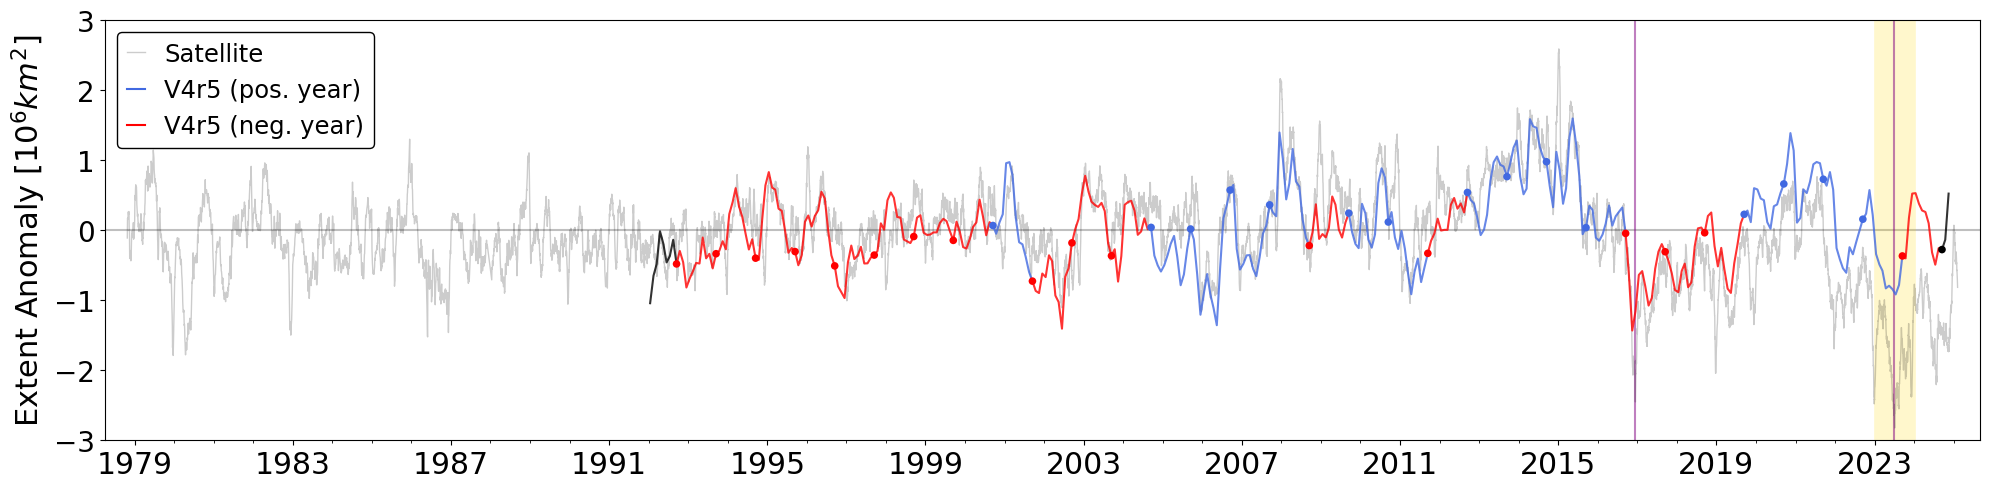

In [15]:
def get_year_color(date):
    d = pd.Timestamp(date)
    year = d.year if d.month >= 9 else d.year - 1
    if year in pos_years:
        return 'royalblue'
    elif year in neg_years:
        return 'red'
    else:
        return 'k'

fig, ax = plt.subplots(figsize=(20,5))

plt.axhline(0, c='gray', alpha=0.5)
plt.axvline(pd.to_datetime('2023-07-07', format='%Y-%m-%d'), color='gold', alpha=0.2, linewidth=30)
plt.axvline(pd.to_datetime('2016-12-10', format='%Y-%m-%d'), color='purple', linestyle='-', alpha=0.5)
plt.axvline(pd.to_datetime('2023-07-01', format='%Y-%m-%d'), color='purple', linestyle='-', alpha=0.5)

pos_years = set(pos_weights.keys())
neg_years = set(neg_weights.keys())

# Satellite line
plt.plot('date', 'anom_ext', data=daily_nsidc_sie, color='k', linewidth=1, alpha=0.2, label='Satellite')

# ECCO V4r5 line, colored by positive/negative year
ecco_dates = si_areas_df_units['datetime_obj'].values
ecco_sie_anoms = si_areas_df_units['sie_anom'].values

i = 0
while i < len(ecco_dates):
    color = get_year_color(ecco_dates[i])
    j = i + 1
    while j < len(ecco_dates) and get_year_color(ecco_dates[j]) == color:
        j += 1
    ax.plot(mdates.date2num(ecco_dates[i:j+1]), ecco_sie_anoms[i:j+1],
            color=color, linewidth=1.5, alpha=0.8,
            label='ECCO V4r5' if i == 0 else None)
    i = j

# plot September points on ECCO line
# ecco_df = si_areas_df_units.copy()
# ecco_df['datetime_obj'] = pd.to_datetime(ecco_df['datetime_obj'])
sept_ecco = si_areas_df_units[si_areas_df_units['datetime_obj'].dt.month == 9]

for _, row in sept_ecco.iterrows():
    color = get_year_color(row['datetime_obj'])
    ax.scatter(mdates.date2num(row['datetime_obj']), row['sie_anom'],
               color=color, s=30, zorder=5, edgecolors='none')

legend_elements = [
    Line2D([0], [0], color='k',         linewidth=1,   alpha=0.2, label='Satellite'),
    Line2D([0], [0], color='royalblue', linewidth=1.5, label='V4r5 (pos. year)'),
    Line2D([0], [0], color='red',       linewidth=1.5, label='V4r5 (neg. year)'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=17.5, edgecolor='black', 
          handlelength=0.75, framealpha=1)

plt.ylabel('Extent Anomaly [$10^6 km^2$]', fontsize=22)
plt.yticks(size=20)
plt.ylim(-3, 3)

plt.xticks(size=21.5)
years = np.arange(1979, 2026, 4)
ax.set_xticks([mdates.date2num(mdates.datetime.datetime(year, 1, 1)) for year in years])
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.YearLocator(1))
ax.set_xlim(left=mdates.datestr2num("1978-04-01"), right=mdates.datestr2num("2025-09-01"))

plt.tight_layout()
# plt.savefig('manuscript_figs/sie_anom_ts_wecco_coloredanom.png', bbox_inches='tight')

## Set-up for WMT calculation with ECCO V4r5

### ECCO V4r5 variable names + descriptions
Freshwater fluxes
- $\textbf{oceFWflx}$ [$kg m^{-2} s^{-1}$]: Net surface Fresh-Water flux into the ocean (+=down), >0 decreases salinity
- $\textbf{SIatmFW}$ [$kg m^{-2} s^{-1}$]: Net freshwater flux from atmosphere & land (+=down)

Heat flux
- $\textbf{oceQnet}$ [$Wm^{-2}$]: Net heat flux into the ocean surface
 
Surface properties
- $\textbf{THETA}$ [$^{\circ}C$]: Potential temperature
- $\textbf{SALT}$ [1e-3]: Salinity

### Define positive/negative SIE years for composite analysis 

In [16]:
# Helper: assign a "Sep-based" year label
def sep_based_year(date):
    """Return the year label for a Sep–Aug year."""
    if date.month >= 9:
        return date.year
    else:
        return date.year - 1

In [17]:
# Split intervals into positive and negative groups
pos_intervals = []
neg_intervals = []

# Save weights of each interval
pos_yr_weights = []
neg_yr_weights = []

pos_period_years = []
neg_period_years = []

for hour in hour_intervals:
    date = v4r5_wmt_func.iteration_to_date(hour)
    year_label = sep_based_year(date)
    if year_label in max_pos_yrs:
        pos_intervals.append(hour)
        pos_period_years.append(year_label)
        pos_yr_weights.append(pos_weights[year_label])
    elif year_label in max_neg_yrs:
        neg_intervals.append(hour)
        neg_period_years.append(year_label)
        neg_yr_weights.append(neg_weights[year_label])
posneg_intervals = [pos_intervals, neg_intervals]
weights = [pos_yr_weights, neg_yr_weights]

# Print summary
group_names = ['positive', 'negative']
print('Number of groups: ', len(posneg_intervals))

for i, period_intervals in enumerate(posneg_intervals):
    if len(period_intervals) == 0:
        print(f"\n{group_names[i]} group: no data found")
        continue
    print()
    print(f'{group_names[i]} group:')
    print('  First date: ', v4r5_wmt_func.iteration_to_date(period_intervals[0]))
    print('  Last date:  ', v4r5_wmt_func.iteration_to_date(period_intervals[-1]))
    print('  Length (months): ', len(period_intervals))

Number of groups:  2

positive group:
  First date:  2000-09-30 00:00:00
  Last date:   2023-08-31 00:00:00
  Length (months):  180

negative group:
  First date:  1992-09-30 00:00:00
  Last date:   2024-08-31 00:00:00
  Length (months):  204


### Load ECCO V4r5 outputs 

In [18]:
ecco_vars = ['THETA', 'SALT', 'oceQnet', 'oceFWflx', 'SIatmFW']
file_vars = {
    'sst': 'THETA',
    'sss': 'SALT',
    'sfc_hflux_coupler': 'oceQnet',
    'pme_river': 'oceFWflx',
    'melt': ['oceFWflx', 'SIatmFW']
}
var_pop = list(file_vars.keys())

# single cache: cache[ecco_varname][hr] = daily_vals
loaded_vals_cache = {varname: {} for varname in ecco_vars}

def get_cached_val(ecco_varname, hr):
    """Load once and be able to reuse afterwards"""
    if hr not in loaded_vals_cache[ecco_varname]:
        loaded_vals_cache[ecco_varname][hr] = v4r5_wmt_func.load_reproject_values(ecco_varname, hr)
    return loaded_vals_cache[ecco_varname][hr]

def build_R(hr_intervals):
    """Build the R dict (var_pop keys) for a given list of hour_intervals."""
    R = {}
    for og_var_name, ecco_varname in file_vars.items():
        if og_var_name == 'melt':
            incl_si, no_si = ecco_varname
            R[og_var_name] = [get_cached_val(incl_si, hr) - get_cached_val(no_si, hr) for hr in hr_intervals]
        else:
            R[og_var_name] = [get_cached_val(ecco_varname, hr) for hr in hr_intervals]
    return R

R = build_R(hour_intervals)
R_all = [build_R(posneg_hr_intervals) for posneg_hr_intervals in posneg_intervals]
print(R.keys())
print(R_all[0].keys())

dict_keys(['sst', 'sss', 'sfc_hflux_coupler', 'pme_river', 'melt'])
dict_keys(['sst', 'sss', 'sfc_hflux_coupler', 'pme_river', 'melt'])


(180, 360) (180, 360) (180, 360)

Plot of native grid area:


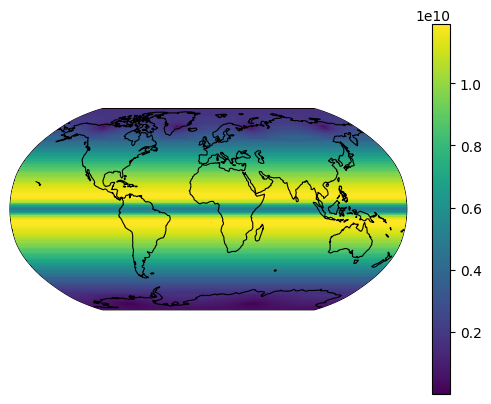

In [19]:
grid_fp = '/home/dmenemen/eady-data1/grid/ECCO_V4r5/'
ecco_XC = ecco.read_llc_to_tiles(grid_fp, 'XC.data', less_output=True)
ecco_YC = ecco.read_llc_to_tiles(grid_fp, 'YC.data', less_output=True)
ecco_RAC = ecco.read_llc_to_tiles(grid_fp, 'RAC.data', less_output=True)
projected_dummy_area = ecco.plot_proj_to_latlon_grid(ecco_XC, ecco_YC, ecco_RAC, show_colorbar=True, 
                                                     show_land=False, dx=grid_size, dy=grid_size);
X, Y = projected_dummy_area[4], projected_dummy_area[5]

with open(f'/home/szhang6/wmt/ecco_v4r5_{grid_size_str}deg_areas.pkl', 'rb') as f:
    area = pickle.load(f)

print(X.shape, Y.shape, area.shape)
print('\nPlot of native grid area:')

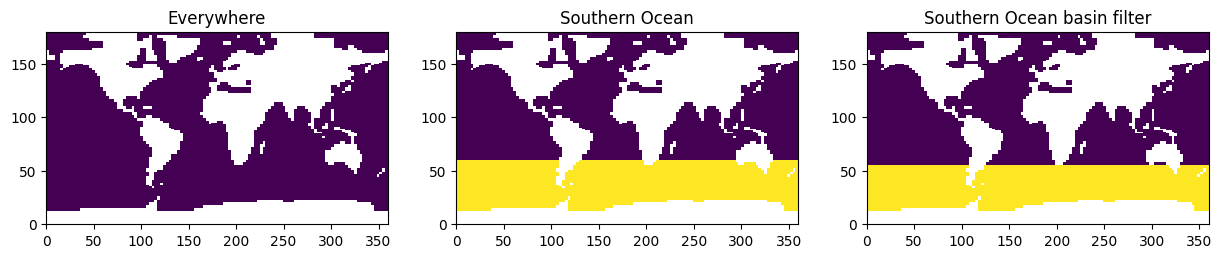

In [20]:
basin_file = netcdf.Dataset(f'basin_mask_regridded_ecco_v4r5_{grid_size_str}deg.nc')
basins = basin_file.variables['BASIN_MASK'][:]

SH = Y <= -30
SO = basins == 1
TOT = basins > 0

hems = ['TOT', 'SH', 'SO']
hem = [TOT, SH, SO]

# PLOT BASIN FILTERS:
fig, axs = plt.subplots(1,3, figsize=(15,2.5))
axs[0].pcolormesh(TOT)
axs[0].set_title('Everywhere');
axs[1].pcolormesh(TOT * SH)
axs[1].set_title('Southern Ocean');
axs[2].pcolormesh(SO)
axs[2].set_title('Southern Ocean basin filter');

## Calculate overall WMT rate

### WMT rates

From Newsom et al. 2021:

Global overturning streamfunction from the residual circulation along and across density surfaces, given by:
    
$$
\begin{align}
\psi(y, \sigma) \equiv - \int_{-h}^{ζ} \int_{x_E}^{x_W} \textbf{v}(x,y,z)H(\sigma'(\textbf{x}) - \sigma) dxdz
\tag{1}
\end{align}
$$

Eq. (1) quantifies the meridional transport of waters denser than isopycnal σ, where 
- $\psi$ is the ciculation across a given density class
- **v**$(x, y, z)$ is the local residual meridional velocity (including bolus contributions)
- $h$ is the depth of the ocean bottom
- $ζ$ the sea surface height
- $H$ is the Heaviside Function, where H(n) = 1 for n ≥ 0 and H(n) = 0 for n < 0
- $x_E$ and $x_W$ are zonal boundaries of the domain, which can span a closed basin or a full longitude circle
- $y$ is latitude.


Surface water mass transformation:
$$
\begin{align}
F(y, \sigma) = \frac{\delta}{\delta\sigma} \int_{A[\sigma' > \sigma]} f_{surf}H(\sigma'(\textbf{x}) - \sigma_{min}(y))dA
\tag{5}
\end{align}
$$

where $f_{surf}$ is the local surface buoyancy flux:

$$
\begin{align}
f_{surf}(x,y,t) = -\frac{\alpha}{c_p}f_H(x,y,t) - \frac{\rho_0}{\rho_{FW}}\beta S_0 f_{FW}(x,y,t)
\tag{6}
\end{align}
$$
- $\sigma_{min}(y)$ is the minimum density at latitude y
- $A$ is the surface outcrop area for all densities greater than a given density, $\sigma$
- $α$ is the coefficient of thermal expansion
- $β$ is the coefficient of haline contraction 
- $f_H$ is the surface heat flux
- $f_FW$ is the surface freshwater flux
- $ρ_0$ is the reference density
- $ρ_{FW}$ is the freshwater density
- $S_0$ is the salinity

In [21]:
p = 2000 # sigma_2
# p = 0 # uncomment this for sigma_0 instead of sigma_2
rho0 = 1032 # reference density
grho = -9.8 / rho0 # for converting from Fsigma to Fb

rhomax = 1024
rhomin = 1039
nlevs = 300 # 0.05 kg m^-3 density bins
rholevs = np.linspace(rhomax, rhomin, nlevs)

In [22]:
a, b = TOT.shape

def calculate_wmt_full(R_full, Nt):
    """Compute per-timestep transformation rates and density fields once, for the full time series."""
    cp = 3994  # specific heat at constant pressure
    
    trans_full, trans_si_full = {}, {}
    rho_full = {}
    Fdens_heat_full, Fdens_salt_full, Fdens_si_full = {}, {}, {}

    for hem_i, hem_name in enumerate(hems):
        mask = TOT.copy() * hem[hem_i]

        trans = np.zeros((Nt, 2, len(rholevs) - 1))
        trans_si = np.zeros((Nt, 2, len(rholevs) - 1))
        rho = np.zeros((Nt, a, b))
        Fdens_heat = np.zeros((Nt, a, b))
        Fdens_salt = np.zeros((Nt, a, b))
        Fdens_si = np.zeros((Nt, a, b))

        for f in range(Nt):
            s = gsw.SA_from_SP(np.squeeze(R_full[var_pop[1]][f]) * hem[hem_i], 1, X, Y)  # sss
            t = gsw.CT_from_pt(s, np.squeeze(R_full[var_pop[0]][f]) * hem[hem_i])  # sst
            hf = np.squeeze(R_full[var_pop[2]][f]) * hem[hem_i]  # heat flux
            fw = np.squeeze(R_full[var_pop[3]][f]) * hem[hem_i]  # freshwater flux
            si = np.squeeze(R_full[var_pop[4]][f]) * hem[hem_i]  # SI freshwater flux
            hem_area = area.copy() * hem[hem_i]

            rho[f], drhodT, drhodS = gsw.rho_alpha_beta(s, t, p)

            Fdens_heat[f] = (-drhodT / cp * hf) * hem_area
            Fdens_salt[f] = (-drhodS / 1000 * s * fw * 1032) * hem_area
            Fdens_si[f]   = (-drhodS / 1000 * s * si * 1032) * hem_area

            trans[f]    = v4r5_wmt_func.calculate_transformation_rate(rho[f], hem_area, mask, rholevs, Fdens_heat[f], Fdens_salt[f])
            trans_si[f] = v4r5_wmt_func.calculate_transformation_rate(rho[f], hem_area, mask, rholevs, Fdens_heat[f], Fdens_si[f])

        trans_full[hem_name] = trans
        trans_si_full[hem_name] = trans_si
        rho_full[hem_name] = rho
        Fdens_heat_full[hem_name] = Fdens_heat
        Fdens_salt_full[hem_name] = Fdens_salt
        Fdens_si_full[hem_name] = Fdens_si

    return {
        'trans': trans_full,
        'trans_si': trans_si_full,
        'rho': rho_full,
        'Fdens_heat': Fdens_heat_full,
        'Fdens_salt': Fdens_salt_full,
        'Fdens_si': Fdens_si_full,
    }

In [23]:
Nt = len(R['sst'])
wmt_full = calculate_wmt_full(R, Nt)

TRANS, TRANS_SI = {}, {}
trans_ann_tot = {}
TRANS_sd, TRANS_SI_sd = {}, {}
FW_NO_SI_sd = {}
nyears = Nt // 12

for hem_name in hems:
    trans = wmt_full['trans'][hem_name]
    trans_si = wmt_full['trans_si'][hem_name]

    TRANS[hem_name] = np.nanmean(trans, axis=0)
    TRANS_SI[hem_name] = np.nanmean(trans_si, axis=0)

    trans_yr = trans[:nyears*12].reshape(nyears, 12, *trans.shape[1:])
    trans_si_yr = trans_si[:nyears*12].reshape(nyears, 12, *trans_si.shape[1:])
    trans_ann = np.nanmean(trans_yr, axis=1)
    trans_si_ann = np.nanmean(trans_si_yr, axis=1)
    
    trans_ann_tot[hem_name] = trans_ann.sum(axis=1) # annual WMT rates
    TRANS_sd[hem_name] = np.nanstd(trans_ann, axis=0)
    TRANS_SI_sd[hem_name] = np.nanstd(trans_si_ann, axis=0)
    FW_NO_SI_sd[hem_name] = np.nanstd(trans_ann[:, 1, :] - trans_si_ann[:, 1, :], axis=0)

In [24]:
hr_index = {hr: idx for idx, hr in enumerate(hour_intervals)}

outputs_periods = []
rhos_periods = []

for i, hrs_group in enumerate(posneg_intervals):
    idx = [hr_index[hr] for hr in hrs_group]
    period_weights = np.array(weights[i])

    TRANS_p, TRANS_SI_p = {}, {}
    rhos_period = {}

    for hem_name in hems:
        trans_sub = wmt_full['trans'][hem_name][idx]
        trans_si_sub = wmt_full['trans_si'][hem_name][idx]

        TRANS_p[hem_name]    = np.sum(trans_sub * period_weights[:, None, None], axis=0) / period_weights.sum()
        TRANS_SI_p[hem_name] = np.sum(trans_si_sub * period_weights[:, None, None], axis=0) / period_weights.sum()
        rhos_period[hem_name] = wmt_full['rho'][hem_name][idx]

    rhos_periods.append(rhos_period)

    hem_plot = 'SO'
    yt  = TRANS_p[hem_plot].sum(axis=0) / 1e6
    yh  = TRANS_p[hem_plot][0, :] / 1e6
    yfw = TRANS_p[hem_plot][1, :] / 1e6
    ysi = TRANS_SI_p[hem_plot][1, :] / 1e6
    outputs_periods.append([yt, yh, yfw, ysi])

In [25]:
all_period_hrs = {hr for group in posneg_intervals for hr in group}
assert all_period_hrs.issubset(set(hour_intervals)), "period hrs contain values not in hour_intervals"

### Surface buoyancy flux ($F_b$) and outcrop area ($A$)

In [26]:
SO_mask = hem[2]
SO_grid_areas = area.copy() * SO_mask
SO_grid_areas = SO_grid_areas.filled(np.nan)

In [27]:
Fdens_heat = wmt_full['Fdens_heat']['SO']
Fdens_salt = wmt_full['Fdens_salt']['SO']
Fdens_si = wmt_full['Fdens_si']['SO']
rho_SO = wmt_full['rho']['SO']

In [28]:
F_monthly = (Fdens_heat + Fdens_salt) / SO_grid_areas
print("F_monthly shape: ", F_monthly.shape)

# rho_SO = rho * hem[1]
print("rho_SO shape: ", rho_SO.shape)

# CONVERT TO ANNUAL
num_yrs = int(np.floor(len(F_monthly) / 12))

F_annual = np.zeros((num_yrs, F_monthly[0].shape[0], F_monthly[0].shape[1]))
print("F_annual shape: ", F_annual.shape)

rho_SO_annual = np.zeros((num_yrs, rho_SO[0].shape[0], rho_SO[0].shape[1]))
print("rho_SO_annual shape: ", rho_SO_annual.shape)

for year_i in np.arange(num_yrs):
    start_month = year_i * 12
    end_month = start_month + 12
    
    all_months_this_yr_F = F_monthly[start_month:end_month]
    F_yr = np.nanmean(all_months_this_yr_F, axis=0)
    F_annual[year_i,:,:] = F_yr

    all_months_this_yr_rho = rho_SO[start_month:end_month]
    rho_yr = np.nanmean(all_months_this_yr_rho, axis=0)
    rho_SO_annual[year_i,:,:] = rho_yr

F_monthly shape:  (395, 180, 360)
rho_SO shape:  (395, 180, 360)
F_annual shape:  (32, 180, 360)
rho_SO_annual shape:  (32, 180, 360)


/tmp/ipykernel_1511836/236027695.py:1: RuntimeWarning: invalid value encountered in divide
  F_monthly = (Fdens_heat + Fdens_salt) / SO_grid_areas
/tmp/ipykernel_1511836/236027695.py:21: RuntimeWarning: Mean of empty slice
  F_yr = np.nanmean(all_months_this_yr_F, axis=0)
/tmp/ipykernel_1511836/236027695.py:25: RuntimeWarning: Mean of empty slice
  rho_yr = np.nanmean(all_months_this_yr_rho, axis=0)


In [29]:
F_copy = F_annual.copy()
area_weighting = SO_grid_areas / np.nansum(SO_grid_areas)

# Initialize array: (395 months, 300 density classes)
annual_F_sums = np.zeros((len(rho_SO_annual), len(rholevs) - 1))
annual_A_sums = np.zeros((len(rho_SO_annual), len(rholevs) - 1))

for i, annual_rho in enumerate(rho_SO_annual):
    for j in range(len(rholevs) - 1):
        dens_range = [rholevs[j], rholevs[j + 1]]
        
        # Create mask for this density class
        mask = (np.isnan(annual_rho) | (annual_rho < dens_range[0]) | (annual_rho >= dens_range[1]))
        
        # Create temporary copies for this density class
        F_temp = F_copy[i].copy()
        F_temp[mask] = np.nan

        A_temp = SO_grid_areas.copy()
        A_temp[mask] = np.nan

        # Calculated sum (not area-weighted) for this density class
        area_densclass = np.nansum(A_temp)
        annual_A_sums[i, j] = area_densclass
        annual_F_sums[i, j] = np.nansum(F_temp * A_temp) / area_densclass
        
annual_F_sums.shape, annual_A_sums.shape

/tmp/ipykernel_1511836/1157146729.py:25: RuntimeWarning: invalid value encountered in scalar divide
  annual_F_sums[i, j] = np.nansum(F_temp * A_temp) / area_densclass


((32, 299), (32, 299))

In [30]:
A = annual_A_sums
A_bar = np.nanmean(A, axis=0)
A_prime = A - A_bar

F = annual_F_sums
F_bar = np.nanmean(F, axis=0)
F_prime = F - F_bar

print(f"F shape: {F.shape}")
print(f"F_bar shape: {F_bar.shape}")
print(f"F' shape: {F_prime.shape}")

print()

print(f"A shape: {A.shape}")
print(f"A_bar shape: {A_bar.shape}")
print(f"A' shape: {A_prime.shape}")

F shape: (32, 299)
F_bar shape: (299,)
F' shape: (32, 299)

A shape: (32, 299)
A_bar shape: (299,)
A' shape: (32, 299)


/tmp/ipykernel_1511836/1881836306.py:6: RuntimeWarning: Mean of empty slice
  F_bar = np.nanmean(F, axis=0)


## Figure 2

In [31]:
plot_hem = 'SO'

# --- means ---
yt  = TRANS[plot_hem].sum(axis=0) / 1e6
yh  = TRANS[plot_hem][0, :] / 1e6
yfw = TRANS[plot_hem][1, :] / 1e6
ysi = TRANS_SI[plot_hem][1, :] / 1e6
yfw_minus_ysi = yfw - ysi

# --- standard deviations ---
yt_sd  = np.nanstd(trans_ann_tot['SO'], axis=0) / 1e6
yh_sd  = TRANS_sd[plot_hem][0, :] / 1e6
yfw_sd = TRANS_sd[plot_hem][1, :] / 1e6
ysi_sd = TRANS_SI_sd[plot_hem][1, :] / 1e6
yfw_minus_ysi_sd = FW_NO_SI_sd[plot_hem] / 1e6

sigma2s = rholevs[1:] - 1000

# --- smooth everything ---
yt_s    = savgol_filter(yt, window_size, poly_order)
yh_s    = savgol_filter(yh, window_size, poly_order)
yfwsi_s = savgol_filter(yfw_minus_ysi, window_size, poly_order)
ysi_s   = savgol_filter(ysi, window_size, poly_order)

yt_sd_s    = savgol_filter(yt_sd, window_size, poly_order)
yh_sd_s    = savgol_filter(yh_sd, window_size, poly_order)
yfwsi_sd_s = savgol_filter(yfw_minus_ysi_sd, window_size, poly_order)
ysi_sd_s   = savgol_filter(ysi_sd, window_size, poly_order)

/tmp/ipykernel_1511836/339602878.py:54: RuntimeWarning: divide by zero encountered in log10
  l2, = ax2.plot(sigma2s, np.log10(A_bar), label=r'$\overline{A}$', color=Abar_color, linestyle='--', lw=3)


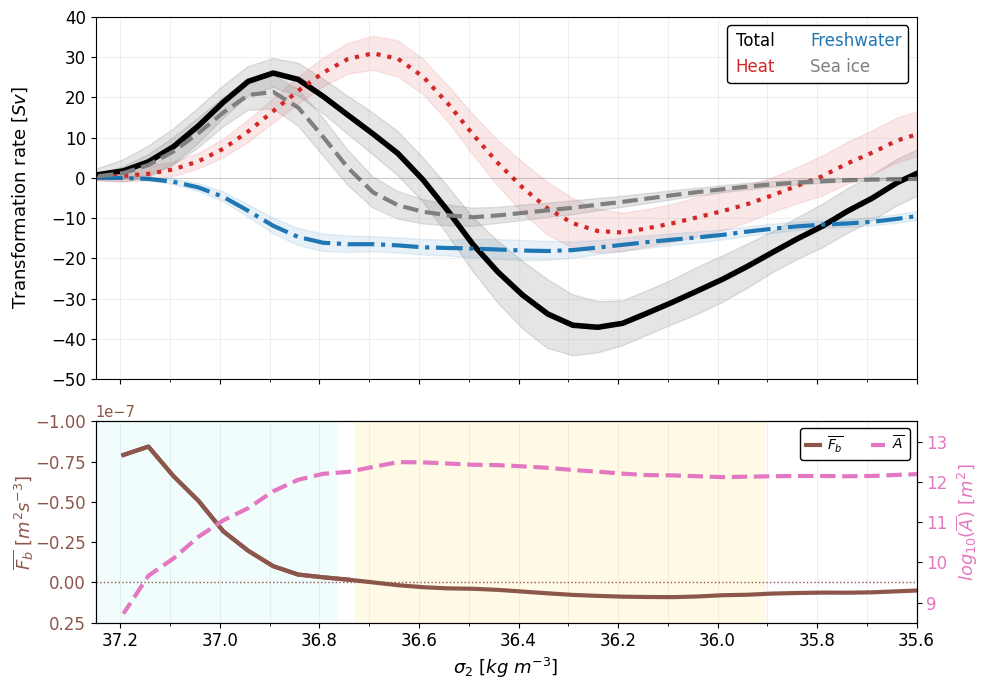

In [32]:
fig, axs = plt.subplots(2, figsize=(10, 7), sharex=True, gridspec_kw={'height_ratios': [4.5, 2.5]})

# ========== PANEL 1 ==========
panel1 = axs[0]
plot_hem = 'SO'

# --- plot lines (original styles) ---
panel1.plot(sigma2s, yt_s,    c='k',        linewidth=4)
panel1.plot(sigma2s, yh_s,    c='tab:red',  linewidth=3, linestyle='dotted')
panel1.plot(sigma2s, yfwsi_s, c='tab:blue', linewidth=3, linestyle='-.')
panel1.plot(sigma2s, ysi_s,   c='tab:gray', linewidth=3, linestyle='--')
# panel1.plot(sigma2s, ysi_s + yfwsi_s,   c='pink', linewidth=3, linestyle='--')

# --- shading ---
panel1.fill_between(sigma2s, yt_s - yt_sd_s,       yt_s + yt_sd_s,       color='k',        alpha=0.1)
panel1.fill_between(sigma2s, yh_s - yh_sd_s,       yh_s + yh_sd_s,       color='tab:red',  alpha=0.1)
panel1.fill_between(sigma2s, yfwsi_s - yfwsi_sd_s, yfwsi_s + yfwsi_sd_s, color='tab:blue', alpha=0.1)
panel1.fill_between(sigma2s, ysi_s - ysi_sd_s,     ysi_s + ysi_sd_s,     color='tab:gray', alpha=0.2)

panel1.axhline(0, color="k", linewidth=0.8, alpha=0.15)
panel1.legend(['Total','Heat','Freshwater','Sea ice'], fontsize='large', loc='upper right', handlelength=0, 
          handletextpad=0.1, ncol=2, labelcolor=wmt_colors, edgecolor='black', framealpha=1)

panel1.set_xlim(sigma2_xlim)
panel1.set_ylim([-50, 40])

panel1.xaxis.grid(True, which='both', alpha=grid_alpha)
panel1.yaxis.grid(True, alpha=grid_alpha)
panel1.xaxis.set_minor_locator(MultipleLocator(0.1))
panel1.tick_params(axis='both', labelsize=tick_labelsize)
panel1.set_ylabel("Transformation rate [$Sv$]", fontsize=label_fontsize)

# ========== PANEL 2 ==========
ax = axs[1]
ax2 = ax.twinx()

ax.axvline(rholevs[260] - 1000, c='paleturquoise', alpha=0.17, linewidth=201)
ax.axvline(rholevs[246] - 1000.025, c='gold', alpha=0.1, linewidth=296)

Fbar_color = 'tab:brown'
Abar_color = 'tab:pink'
Fbar_buoyancy = F_bar * grho
l1, = ax.plot(sigma2s, Fbar_buoyancy, label=r'$\overline{F_b}$', color=Fbar_color, linestyle='-', lw=3)
# Positive values: solid
F_neg = np.ma.masked_where(Fbar_buoyancy > 0, Fbar_buoyancy)
l1ish, = ax.plot(
    sigma2s, F_neg,
    color=Fbar_color,
    linestyle='-',
    lw=3,
)
ax.axhline(0, lw=1, color=Fbar_color, linestyle=':')

l2, = ax2.plot(sigma2s, np.log10(A_bar), label=r'$\overline{A}$', color=Abar_color, linestyle='--', lw=3)

ax.legend(handles=[l1, l2], fontsize='medium', loc='upper right', handlelength=1, 
          ncol=2, handletextpad=0.5, edgecolor='black', framealpha=1)

ax.set_xlim(sigma2_xlim)
ax.set_ylim(.25e-7, -1e-7)
ax2.set_ylim(8.5, 13.5)

ax.xaxis.grid(True, which='both', alpha=grid_alpha)
ax.xaxis.set_minor_locator(MultipleLocator(0.1))
ax.tick_params(axis='y', labelcolor=Fbar_color)
ax2.tick_params(axis='y', labelcolor=Abar_color)
ax.tick_params(axis='both', labelsize=tick_labelsize)
ax2.tick_params(axis='both', labelsize=tick_labelsize)
ax.yaxis.get_offset_text().set_fontsize(tick_labelsize - 1.5)

ax.set_xlabel(r"$\sigma_2$ [$kg~m^{-3}$]", fontsize=label_fontsize)
ax.set_ylabel(r'$\overline{F_b}~[m^{2}s^{-3}]$', color=Fbar_color, labelpad=0, fontsize=label_fontsize)
ax2.set_ylabel(r'$log_{10}(\overline{A})~[m^2]$', color=Abar_color, labelpad=5, fontsize=label_fontsize)

fig.align_ylabels(axs)
fig.tight_layout()
fig.subplots_adjust(hspace=0.15)
plt.show()
fig.savefig('manuscript_figs/overall_wmt_combined_log10A_flippedFb.png', dpi=1200)

In [33]:
print(f'Mean Fb in sea ice formation region: {np.nanmean(Fbar_buoyancy[254:264])}')
print(f'Mean Fb in sea ice melt region: {np.nanmean(Fbar_buoyancy[237:253])}')

Mean Fb in sea ice formation region: -3.886534804484163e-08
Mean Fb in sea ice melt region: 6.0855194514099415e-09


In [34]:
# ### UNCOMMENT TO PLOT F_sigma INSTEAD OF F_b ####
# fig, axs = plt.subplots(2, figsize=(10, 7), sharex=True, gridspec_kw={'height_ratios': [4.5, 2.5]})

# # ========== PANEL 1 ==========
# ax = axs[0]
# plot_hem = 'SO'

# # --- plot lines (original styles) ---
# ax.plot(sigma2s, yt_s,    c='k',        linewidth=4)
# ax.plot(sigma2s, yh_s,    c='tab:red',  linewidth=3, linestyle='dotted')
# ax.plot(sigma2s, yfwsi_s, c='tab:blue', linewidth=3, linestyle='-.')
# ax.plot(sigma2s, ysi_s,   c='tab:gray', linewidth=3, linestyle='--')
# # --- shading ---
# ax.fill_between(sigma2s, yt_s - yt_sd_s,       yt_s + yt_sd_s,       color='k',        alpha=0.1)
# ax.fill_between(sigma2s, yh_s - yh_sd_s,       yh_s + yh_sd_s,       color='tab:red',  alpha=0.1)
# ax.fill_between(sigma2s, yfwsi_s - yfwsi_sd_s, yfwsi_s + yfwsi_sd_s, color='tab:blue', alpha=0.1)
# ax.fill_between(sigma2s, ysi_s - ysi_sd_s,     ysi_s + ysi_sd_s,     color='tab:gray', alpha=0.2)

# ax.axhline(0, color="k", linewidth=0.8)
# ax.legend(['Total','Heat','Freshwater','Sea ice'], fontsize='large', loc='upper right', handlelength=0, 
#           handletextpad=0.1, ncol=2, labelcolor=wmt_colors, edgecolor='black', framealpha=1)

# ax.set_xlim(sigma2_xlim)
# ax.set_ylim([-50, 40])

# ax.tick_params(axis='both', labelsize=tick_labelsize)
# ax.grid(True, axis="both", alpha=grid_alpha)
# ax.xaxis.grid(True, which='both', alpha=grid_alpha)
# ax.yaxis.grid(True, alpha=grid_alpha)
# ax.xaxis.set_minor_locator(MultipleLocator(0.1))
# ax.set_ylabel("Transformation rate [$Sv$]", fontsize=label_fontsize)

# # ========== PANEL 2 ==========
# ax = axs[1]
# ax2 = ax.twinx()

# ax.axvline(rholevs[260] - 1000, c='paleturquoise', alpha=0.17, linewidth=201)
# ax.axvline(rholevs[246] - 1000.025, c='gold', alpha=0.1, linewidth=296)

# Fbar_color = 'tab:brown'
# Abar_color = 'tab:pink'
# l1, = ax.plot(sigma2s, F_bar, label=r'$\overline{F_\sigma}$', color=Fbar_color, linestyle='-', lw=3)
# # Positive values: solid
# F_pos = np.ma.masked_where(F_bar < -0.01e-5, F_bar)
# l1ish, = ax.plot(
#     sigma2s, F_pos,
#     color=Fbar_color,
#     linestyle='-',
#     lw=3,
# )
# ax.axhline(0, lw=1, color=Fbar_color, linestyle=':')

# l2, = ax2.plot(sigma2s, np.log10(A_bar), label=r'$\overline{A}$', color=Abar_color, linestyle='--', lw=3)

# ax.legend(handles=[l1, l2], fontsize='medium', loc='upper right', handlelength=1, 
#           ncol=2, handletextpad=0.5, edgecolor='black', framealpha=1)

# ax.set_xlim(sigma2_xlim)
# ax.set_ylim(-0.3e-5, 1.05e-5)
# ax2.set_ylim(8.5, 13.5)

# ax.grid(True, axis="x", alpha=grid_alpha)
# ax.xaxis.grid(True, which='both', alpha=grid_alpha)
# ax.xaxis.set_minor_locator(MultipleLocator(0.1))
# ax.yaxis.get_offset_text().set_fontsize(tick_labelsize - 1.5)
# ax.tick_params(axis='y', labelcolor=Fbar_color)
# ax2.tick_params(axis='y', labelcolor=Abar_color)
# ax.tick_params(axis='both', labelsize=tick_labelsize)
# ax2.tick_params(axis='both', labelsize=tick_labelsize)

# ax.set_xlabel(r"$\sigma_2$ [$kg~m^{-3}$]", fontsize=label_fontsize)
# ax.set_ylabel(r'$\overline{F_\sigma}~[kg~m^{-2}s^{-1}]$', color=Fbar_color, labelpad=0, fontsize=label_fontsize)
# ax2.set_ylabel(r'$log_{10}(\overline{A})~[m^2]$', color=Abar_color, labelpad=5, fontsize=label_fontsize)

# fig.tight_layout()
# fig.subplots_adjust(hspace=0.1)
# plt.show()
# # fig.savefig('manuscript_figs/overall_wmt_combined_log10A_Fsigma.png')

### Uncomment the following cells for $\sigma_0$ plotting:

In [35]:
# fig, axs = plt.subplots(1, figsize=(10, 4.5))
# panel1 = axs
# plot_hem = 'SO'

# # --- plot lines (original styles) ---
# panel1.plot(sigma2s, yt_s,    c='k',        linewidth=4)
# panel1.plot(sigma2s, yh_s,    c='tab:red',  linewidth=3, linestyle='dotted')
# panel1.plot(sigma2s, yfwsi_s, c='tab:blue', linewidth=3, linestyle='-.')
# panel1.plot(sigma2s, ysi_s,   c='tab:gray', linewidth=3, linestyle='--')
# # panel1.plot(sigma2s, ysi_s + yfwsi_s,   c='pink', linewidth=3, linestyle='--')
# # --- shading ---
# panel1.fill_between(sigma2s, yt_s - yt_sd_s,       yt_s + yt_sd_s,       color='k',        alpha=0.1)
# panel1.fill_between(sigma2s, yh_s - yh_sd_s,       yh_s + yh_sd_s,       color='tab:red',  alpha=0.1)
# panel1.fill_between(sigma2s, yfwsi_s - yfwsi_sd_s, yfwsi_s + yfwsi_sd_s, color='tab:blue', alpha=0.1)
# panel1.fill_between(sigma2s, ysi_s - ysi_sd_s,     ysi_s + ysi_sd_s,     color='tab:gray', alpha=0.2)
# panel1.axhline(0, color="k", linewidth=0.8)

# panel1.set_ylim([-55, 30])
# panel1.grid(True, axis="both", alpha=0.5)
# panel1.xaxis.grid(True, which='both', alpha=grid_alpha)
# panel1.yaxis.grid(True, alpha=grid_alpha)
# panel1.xaxis.set_minor_locator(MultipleLocator(0.1))
# panel1.tick_params(axis='both', labelsize=tick_labelsize)
# panel1.set_ylabel("Transformation rate [$Sv$]", fontsize=label_fontsize)

# panel1.legend(['Total','Heat','Freshwater','Sea ice'], fontsize='large', loc='lower right', handlelength=0, 
#           handletextpad=0.1, ncol=2, labelcolor=wmt_colors, edgecolor='black')
# panel1.set_xlim(27.9,25.6)
# # fig.savefig('manuscript_figs/overall_wmt_sigma0.png', dpi=1200)

In [36]:
# # Only include WMT rates within the SI zone
# sigma0_siz_range = [31,78]

# def print_min_max_sigma0(wmts_s, si_ranges=True):
#     rho_range = rholevs.copy()
#     if si_ranges:
#         wmts_s = wmts_s[sigma0_siz_range[0]:sigma0_siz_range[1]]
#         rho_range = rho_range[sigma0_siz_range[0]:sigma0_siz_range[1]]

#     min_rho_i, max_rho_i = np.nanargmin(wmts_s), np.nanargmax(wmts_s)
#     min_rho, max_rho = rho_range[min_rho_i + 1], rho_range[max_rho_i + 1]
#     min_wmt, max_wmt = wmts_s[min_rho_i], wmts_s[max_rho_i]


#     print(f"Min @ {np.round(min_rho, 2)}: {np.round(min_wmt, 3)} Sv")
#     print(f"Max @ {np.round(max_rho, 2)}: {np.round(max_wmt, 3)} Sv")

#     return ([min_rho_i, max_rho_i], [min_rho, max_rho], [min_wmt, max_wmt])

In [37]:
# print("--------- Total ---------")
# print_min_max_sigma0(yt_s);
# print()

# print("--------- Heat ---------")
# print_min_max_sigma0(yh_s);
# print()

# print("--------- FW, excl. sea ice ---------")
# print_min_max_sigma0(yfwsi_s);
# print()

# print("--------- Sea ice ---------")
# print_min_max_sigma0(ysi_s);
# print()

# print("--------- Total FW ---------")
# print_min_max_sigma0(ysi_s + yfwsi_s);
# print()

### Stats

In [38]:
# Only include WMT rates within the SI zone
rho_i_siz = 230

def print_min_max_rho(wmts_s, si_ranges=True):
    rho_range = rholevs.copy()
    if si_ranges:
        wmts_s = wmts_s[rho_i_siz:]
        rho_range = rho_range[rho_i_siz:]

    min_rho_i, max_rho_i = np.nanargmin(wmts_s), np.nanargmax(wmts_s)
    min_rho, max_rho = rho_range[min_rho_i + 1], rho_range[max_rho_i + 1]
    min_wmt, max_wmt = wmts_s[min_rho_i], wmts_s[max_rho_i]


    print(f"Min @ {np.round(min_rho, 2)}: {np.round(min_wmt, 3)} Sv")
    print(f"Max @ {np.round(max_rho, 2)}: {np.round(max_wmt, 3)} Sv")

    return ([min_rho_i, max_rho_i], [min_rho, max_rho], [min_wmt, max_wmt])

def print_max_sd(wmts_sd_s, var_name, si_ranges=True):
    """
    Report the maximum smoothed standard deviation (SD) of the WMT forcing,
    optionally restricted to the sea-ice zone.

    Parameters
    ----------
    wmts_sd_s : array-like
        Pre-smoothed standard deviation values (Sv), e.g. `yt_sd_s`,
        `yh_sd_s`, `yfwsi_sd_s`, or `ysi_sd_s`.
    var_name : str
        Name of the variable being analyzed (e.g. 'total', 'heat'), used
        to label the printed output.
    si_ranges : bool, default True
        If True, restrict the analysis to the sea-ice zone using
        `rho_i_siz:` (and correspondingly trim `rholevs`). If False,
        use the full array.

    Returns
    -------
    max_sd : float
        Maximum smoothed SD value (Sv) within the analyzed range.

    Notes
    -----
    Requires the module-level variables `rholevs` and `rho_i_siz` to
    be defined.
    """
    rho_range = rholevs.copy()
    if si_ranges:
        wmts_sd_s = wmts_sd_s[rho_i_siz:]
        rho_range = rho_range[rho_i_siz:]
    max_sd = np.nanmax(wmts_sd_s)
    print(
        f'{var_name} smoothed max SD @ {np.round(rho_range[np.argmin(max_sd - wmts_sd_s)], 2)}: {np.round(max_sd, 2)} Sv'
    )

In [39]:
print("--------- Total ---------")
print_min_max_rho(yt_s);
print_max_sd(yt_sd_s, 'Total')
print()

print("--------- Heat ---------")
print_min_max_rho(yh_s);
print_max_sd(yh_sd_s, 'Heat')
print()

print("--------- FW, excl. sea ice ---------")
print_min_max_rho(yfwsi_s);
print_max_sd(yfwsi_sd_s, 'Freshwater, excl. SI')
print()

print("--------- Sea ice ---------")
print_min_max_rho(ysi_s);
print_max_sd(ysi_sd_s, 'Sea ice')
print()

print("--------- Total FW ---------")
print_min_max_rho(ysi_s + yfwsi_s);
print()

--------- Total ---------
Min @ 1036.24: -37.104 Sv
Max @ 1036.89: 26.071 Sv
Total smoothed max SD @ 1036.29: 8.55 Sv

--------- Heat ---------
Min @ 1036.19: -13.555 Sv
Max @ 1036.69: 30.976 Sv
Heat smoothed max SD @ 1036.29: 6.58 Sv

--------- FW, excl. sea ice ---------
Min @ 1036.34: -18.149 Sv
Max @ 1037.24: 0.044 Sv
Freshwater, excl. SI smoothed max SD @ 1036.34: 2.5 Sv

--------- Sea ice ---------
Min @ 1036.49: -9.761 Sv
Max @ 1036.89: 21.363 Sv
Sea ice smoothed max SD @ 1036.74: 4.72 Sv

--------- Total FW ---------
Min @ 1036.49: -27.318 Sv
Max @ 1036.94: 12.441 Sv



## Figure 3

### Figure 3a & 3b (WMT composite, differences)

In [40]:
composite_differences = [neg - pos for pos, neg in zip(outputs_periods[0], outputs_periods[1])]

yt_diff = composite_differences[0]
yh_diff = composite_differences[1]
yfw_diff = composite_differences[2]
ysi_diff = composite_differences[3]
yfw_nosi_diff = np.array(yfw_diff) - np.array(ysi_diff)

total - positive min: -37.77229329935586
total - positive max: 27.12717968113172

total - negative min: -38.25224966904932
total - negative max: 25.261275511155645

heat - positive min: -12.547473049504827
heat - positive max: 31.83160356613014

heat - negative min: -15.047712841037265
heat - negative max: 29.805263595081

freshwater - positive min: -18.950606220989577
freshwater - positive max: 1.4068534574397449

freshwater - negative min: -17.831357722414573
freshwater - negative max: 0.9658190665274988

sea ice - positive min: -10.098747554489947
sea ice - positive max: 23.16336691102922

sea ice - negative min: -9.756203547735296
sea ice - negative max: 19.870212401500474



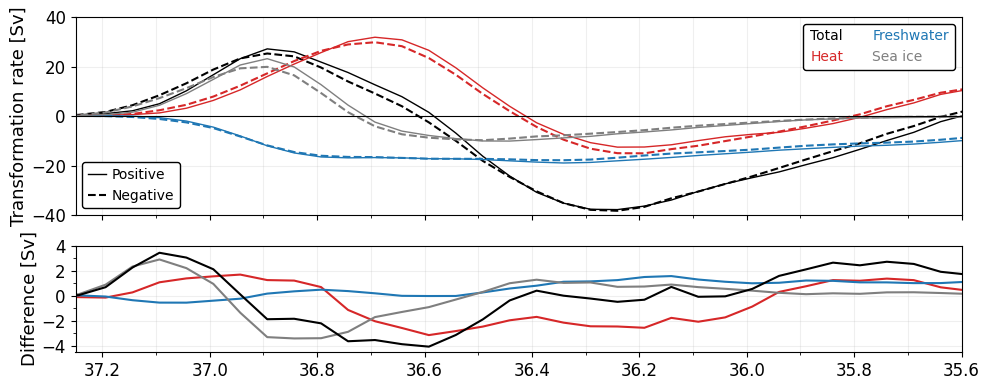

In [41]:
fig, axes = plt.subplots(2, 1, figsize=(10, 4), sharex=True,
                          gridspec_kw={'height_ratios': [3.25, 1.75]})
ax, ax2 = axes
frameon = True

# PANEL 1: composite
for j, (var, color) in enumerate(zip(wmt_vars, wmt_colors)):
    for i, period in enumerate(group_names):
        y = outputs_periods[i][j]
        if var == "freshwater":
            y = y - outputs_periods[i][3]

        y_smooth = savgol_filter(y, window_size, poly_order)

        if i == 0:
            linewidth = 1
            label_adjusted = var.capitalize()
        else:
            linewidth = 1.5
            label_adjusted = ''
        ax.plot(
            sigma2s, y_smooth,
            color=color,
            linestyle=wmt_linestyles[i % len(wmt_linestyles)],
            linewidth=linewidth,
            label=label_adjusted
        )
        
        print(f"{var} - {period} min: {np.nanmin(y_smooth)}")
        print(f"{var} - {period} max: {np.nanmax(y_smooth)}")
        print()

# legend #1: colors -> variables
var_legend = ax.legend(fontsize=legend_fontsize, labelcolor=list(wmt_colors), handlelength=0,
                        handletextpad=0.1, loc='upper right', ncol=2, frameon=frameon, edgecolor='black', framealpha=1)
ax.add_artist(var_legend)  # keep this legend when the second one is added below

# legend #2: linestyles -> periods
style_handles = [
    Line2D([0], [0], color='k',
           linestyle=wmt_linestyles[i % len(wmt_linestyles)],
           linewidth=1 if i == 0 else 1.5,
           label=period.capitalize())
    for i, period in enumerate(group_names)
]
ax.legend(handles=style_handles, fontsize=legend_fontsize, handlelength=1.3,
          handletextpad=0.4, loc='lower left', frameon=frameon, edgecolor='black', framealpha=1)

ax.axhline(0, color="k", linewidth=0.8)

ax.set_xlim(sigma2_xlim)
ax.set_ylim([-40, 40])
ax.xaxis.grid(True, which='both', alpha=grid_alpha)
ax.yaxis.grid(True, alpha=grid_alpha)
ax.xaxis.set_minor_locator(MultipleLocator(0.1))
ax.tick_params(axis='both', labelsize=tick_labelsize)
ax.set_ylabel("Transformation rate [Sv]", fontsize=label_fontsize, labelpad=2)

# PANEL 2: differences
ax2.plot(sigma2s, savgol_filter(yh_diff, window_size, poly_order), c=wmt_colors[1], linewidth=1.5)
ax2.plot(sigma2s, savgol_filter(yfw_nosi_diff, window_size, poly_order), c=wmt_colors[2], linewidth=1.5)
ax2.plot(sigma2s, savgol_filter(ysi_diff, window_size, poly_order), c=wmt_colors[3], linewidth=1.5)
ax2.plot(sigma2s, savgol_filter(yt_diff, window_size, poly_order), c=wmt_colors[0], linewidth=1.5)

ax2.set_xlim(sigma2_xlim)
ax2.set_ylim([-4.5, 4])
ax2.set_yticks(np.arange(-4, 4.1, 2))
ax2.grid(True, axis="both", alpha=grid_alpha)
ax2.xaxis.grid(True, which='both', alpha=grid_alpha)
ax2.xaxis.set_minor_locator(MultipleLocator(0.1))
ax2.yaxis.set_minor_locator(MultipleLocator(1))
ax2.tick_params(axis='both', labelsize=tick_labelsize)
ax2.set_ylabel('Difference [Sv]', fontsize=label_fontsize, labelpad=2)

fig.tight_layout()
fig.subplots_adjust(hspace=0.2)
plt.show()

### Reynolds decomposition: total WMT variance
$F_b$ is the surface buoyancy flux. $A$ is the outcrop area. The Reynolds decomposition uses the following definitions:
- $\overline{\cdot}$: 1992-2024 climatology
- $\cdot'$: annual anomalies from the climatology

Variance decomposition terms are below. The corresponding variable names are included in square brackets.

*Leading order terms:*
- $\overline{F_b'^2}\overline{A}^2$ [a]: Variance due to interannual anomalies in the surface buoyancy flux
- $\overline{F_b}^2\overline{A'^2}$ [b]: Variance due to interannual anomalies in the outcrop area
- $2\overline{F_b}\ \overline{A}\ \overline{F_b'A'}$ [c]: Covariance between anomalies in $F_b$ and $A$

*Higher order terms:*
- $\overline{F_b'^2 A'^2}$ [hot1]
- $2\overline{F_b}\ \overline{F_b' A'^2}$ [hot2]
- $2\overline{A}\ \overline{F_b'^2 A'}$ [hot3]
- $-\overline{F_b' A'}^2$ [hot4]

**var(WMT) = a + b + c + hot1 + hot2 + hot3 + hot4**

#### Calculate variance decomposition

In [42]:
print(f"F shape: {F.shape}")
print(f"F_bar shape: {F_bar.shape}")
print(f"F' shape: {F_prime.shape}")

print()

print(f"A shape: {A.shape}")
print(f"A_bar shape: {A_bar.shape}")
print(f"A' shape: {A_prime.shape}")

F shape: (32, 299)
F_bar shape: (299,)
F' shape: (32, 299)

A shape: (32, 299)
A_bar shape: (299,)
A' shape: (32, 299)


In [43]:
mean_Fprime_Aprime = np.nanmean(F_prime * A_prime, axis=0)

# LEADING ORDER var(WMT) TERMS
a = np.nanmean(F_prime ** 2, axis=0) * (A_bar ** 2)
b = (F_bar ** 2) * np.nanmean(A_prime ** 2, axis=0)
# c = mean_Fprime_Aprime ** 2
c = 2 * F_bar * A_bar * mean_Fprime_Aprime

# HIGHER ORDER var(WMT) TERMS
hot1 = np.nanmean((F_prime ** 2) * (A_prime ** 2), axis=0)
hot2 = 2 * F_bar * np.nanmean(F_prime * (A_prime ** 2), axis=0)
hot3 = 2 * A_bar * np.nanmean((F_prime ** 2) * A_prime, axis = 0)
hot4 = - (mean_Fprime_Aprime ** 2)

# ZEROED OUT TERMS (CONTAINS MEAN OF AN ANOMALY)
zeroed_Aprime = -2 * F_bar * np.nanmean(A_prime, axis=0) * mean_Fprime_Aprime
zeroed_Fprime = -2 * np.nanmean(F_prime, axis=0) * A_bar * mean_Fprime_Aprime

/tmp/ipykernel_1511836/2102041100.py:1: RuntimeWarning: Mean of empty slice
  mean_Fprime_Aprime = np.nanmean(F_prime * A_prime, axis=0)
/tmp/ipykernel_1511836/2102041100.py:4: RuntimeWarning: Mean of empty slice
  a = np.nanmean(F_prime ** 2, axis=0) * (A_bar ** 2)
/tmp/ipykernel_1511836/2102041100.py:10: RuntimeWarning: Mean of empty slice
  hot1 = np.nanmean((F_prime ** 2) * (A_prime ** 2), axis=0)
/tmp/ipykernel_1511836/2102041100.py:11: RuntimeWarning: Mean of empty slice
  hot2 = 2 * F_bar * np.nanmean(F_prime * (A_prime ** 2), axis=0)
/tmp/ipykernel_1511836/2102041100.py:12: RuntimeWarning: Mean of empty slice
  hot3 = 2 * A_bar * np.nanmean((F_prime ** 2) * A_prime, axis = 0)
/tmp/ipykernel_1511836/2102041100.py:17: RuntimeWarning: Mean of empty slice
  zeroed_Fprime = -2 * np.nanmean(F_prime, axis=0) * A_bar * mean_Fprime_Aprime


In [44]:
# INCLUDE ONLY DENSITY CLASSES IN THE SEA ICE ZONE
print(rholevs[231])

def filter_siz_only(vals):
    return vals[230:] # from sigma=1035.59

1035.5886287625417


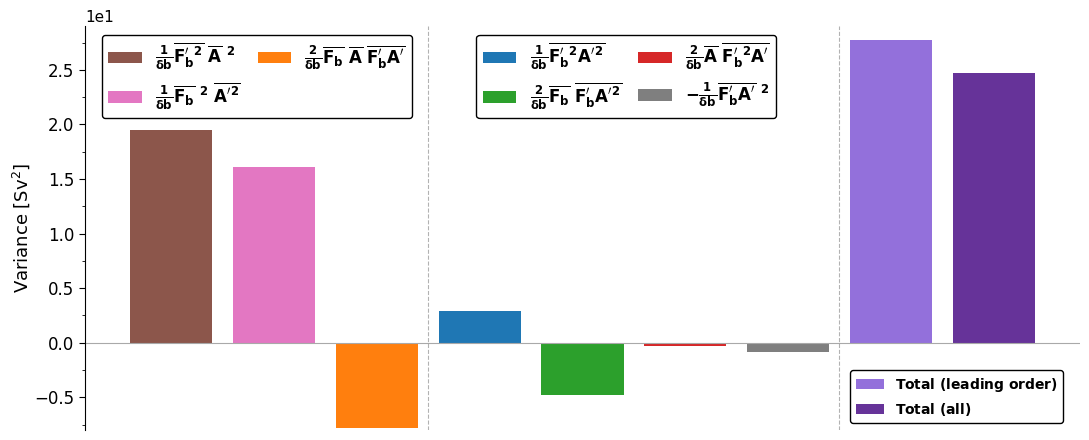

In [60]:
### SUPPLEMENTARY FIGURE ###
fig, ax = plt.subplots(figsize=(11,4.5))
dsigma2 = 0.05 ** 2
values = [np.nanmean(filter_siz_only(a)) / dsigma2 * ((1e-6) ** 2), 
          np.nanmean(filter_siz_only(b)) / dsigma2 * ((1e-6) ** 2), 
          np.nanmean(filter_siz_only(c)) / dsigma2 * ((1e-6) ** 2)] + \
         [np.nanmean(filter_siz_only(hot1)) / dsigma2 * ((1e-6) ** 2), 
          np.nanmean(filter_siz_only(hot2)) / dsigma2 * ((1e-6) ** 2), 
          np.nanmean(filter_siz_only(hot3)) / dsigma2 * ((1e-6) ** 2), 
          np.nanmean(filter_siz_only(hot4)) / dsigma2 * ((1e-6) ** 2), ] + \
         [np.nanmean(filter_siz_only(a + b + c)) / dsigma2 * ((1e-6) ** 2), 
          np.nanmean(filter_siz_only(a + b + c + hot1 + hot2 + hot3 + hot4 + zeroed_Aprime + zeroed_Fprime)) / dsigma2 * ((1e-6) ** 2)]

bar_colors = ['tab:brown', 'tab:pink', 'tab:orange',
              'tab:blue', 'tab:green', 'tab:red', 'tab:grey',
              'mediumpurple',
              'rebeccapurple']

bar_labels = [
    r"$\bf{\frac{1}{\delta b}\overline{F_b'^2}\ \overline{A}\ ^2}$", 
    r"$\bf{\frac{1}{\delta b}\overline{F_b}\ ^2\ \overline{A'^2}}$", 
    r"$\bf{\frac{2}{\delta b}\overline{F_b}\ \overline{A}\ \overline{F_b'A'}}$",
    r"$\bf{\frac{1}{\delta b}\overline{F_b'^2A'^2}}$", # r"HOT$_1$", 
    r"$\bf{\frac{2}{\delta b}\overline{F_b}\ \overline{F_b'A'^2}}$", #r"HOT$_2$",
    r"$\bf{\frac{2}{\delta b}\overline{A}\ \overline{F_b'^2 A'}}$", #r"HOT$_3$",
    r"$\bf{-\frac{1}{\delta b}\overline{F_b' A'}\ ^2}$", # r"HOT$_4$",
    r"$\bf{Total\ (leading\ order)}$",
    r"$\bf{Total\ (all)}$",
]

bar_container = ax.bar([
                        r"$\bf{\overline{F_b'^2}\ \overline{A}\ ^2}$", 
                        r"$\bf{\overline{F_b}\ ^2\ \overline{A'^2}}$", 
                        r"$\bf{2\overline{F_b}\ \overline{A}\ \overline{F_b'A'}}$"] + 
                       [
                        r"HOT$_1$", 
                        r"HOT$_2$",
                        r"HOT$_3$",
                        r"HOT$_4$",] +
                       [
                        'Total (leading order terms)', 
                        'Total (all terms)'], 
                       values,
                       color=bar_colors,
                       label=bar_labels)

ax.set_ylim(-0.8e1, 2.9e1)
ax.tick_params(axis='x', length=0)
ax.set_xticklabels([])
ax.axhline(0, linewidth=0.8, color='darkgrey')
ax.axvline(2.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
ax.axvline(6.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)

# --- y axis ---
formatter = ScalarFormatter()
formatter.set_scientific(True)
formatter.set_powerlimits((-1, 1))
ax.yaxis.set_major_formatter(formatter)
ax.set_yticks(np.arange(-0.5e1, 2.6e1, 0.5e1))
ax.yaxis.set_minor_locator(MultipleLocator(0.25e1))
ax.tick_params(axis='y', labelsize=12, length=4)
ax.yaxis.get_offset_text().set_fontsize(11)
ax.set_ylabel(r'Variance [Sv$^2$]', labelpad=2, fontsize=13)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

# --- legend replaces base labels ---
# ax.legend(fontsize='large', ncol=3, loc='upper center', frameon=True, 
#           edgecolor='black', framealpha=1, bbox_to_anchor=(0.47, 1.0))

handles, labels = ax.get_legend_handles_labels()

# Split into groups: first 3, next 4, last 2
group1 = (handles[0:3], labels[0:3])
group2 = (handles[3:7], labels[3:7])
group3 = (handles[7:9], labels[7:9])

leg1 = ax.legend(*group1, fontsize='large', ncol=2, loc='upper left', columnspacing=1,
                  bbox_to_anchor=(0.0085, 1.0), frameon=True, edgecolor='black', framealpha=1)
leg2 = ax.legend(*group2, fontsize='large', ncol=2, loc='upper left', columnspacing=1,
                  bbox_to_anchor=(0.385, 1.0), frameon=True, edgecolor='black', framealpha=1)
leg3 = ax.legend(*group3, fontsize='medium', ncol=1, loc='lower right',
                  bbox_to_anchor=(0.99, 0), frameon=True, edgecolor='black', framealpha=1)

ax.add_artist(leg1)
ax.add_artist(leg2)

fig.tight_layout()
# fig.savefig('manuscript_figs/var_decomp_bars_allterms.png', dpi=1200)

### Reynolds decomposition: WMT component (heat, sea ice, E-P-R freshwater) variance

#### Surface buoyancy flux ($F_b$) and outcrop area ($A$) for each component

In [46]:
# rerunning this from above, just in case
Fdens_heat = wmt_full['Fdens_heat']['SO']
Fdens_salt = wmt_full['Fdens_salt']['SO']
Fdens_si = wmt_full['Fdens_si']['SO']
rho_SO = wmt_full['rho']['SO']

In [47]:
Fs = {'heat': Fdens_heat / SO_grid_areas, 
      'fw': Fdens_salt / SO_grid_areas, 
      'si': Fdens_si / SO_grid_areas}
# A stays the same

# CONVERT TO ANNUAL
num_yrs = int(np.floor(len(Fs['heat']) / 12))

F_annual_vars = {}
for var_name, F_component in Fs.items():
    F_annual_component = np.zeros((num_yrs, F_component[0].shape[0], F_component[0].shape[1]))

    # don't need to calculate every time, since it doesn't change w/ each var
    if var_name == 'heat': 
        rho_SO_annual = np.zeros((num_yrs, rho_SO[0].shape[0], rho_SO[0].shape[1]))

    for year_i in np.arange(num_yrs):
        start_month = year_i * 12
        end_month = start_month + 12
        
        all_months_this_yr_F = F_component[start_month:end_month]
        F_yr_component = np.nanmean(all_months_this_yr_F, axis=0)
        F_annual_component[year_i,:,:] = F_yr_component

        # don't need to calculate every time, since it doesn't change w/ each var
        if var_name == 'heat':
            all_months_this_yr_rho = rho_SO[start_month:end_month]
            rho_yr = np.nanmean(all_months_this_yr_rho, axis=0)
            rho_SO_annual[year_i,:,:] = rho_yr

    F_annual_vars[var_name] = F_annual_component

print(F_annual_vars['si'].shape)
print(F_annual_vars.keys())

/tmp/ipykernel_1511836/1088444122.py:1: RuntimeWarning: invalid value encountered in divide
  Fs = {'heat': Fdens_heat / SO_grid_areas,
/tmp/ipykernel_1511836/1088444122.py:2: RuntimeWarning: invalid value encountered in divide
  'fw': Fdens_salt / SO_grid_areas,
/tmp/ipykernel_1511836/1088444122.py:3: RuntimeWarning: invalid value encountered in divide
  'si': Fdens_si / SO_grid_areas}
/tmp/ipykernel_1511836/1088444122.py:22: RuntimeWarning: Mean of empty slice
  F_yr_component = np.nanmean(all_months_this_yr_F, axis=0)
/tmp/ipykernel_1511836/1088444122.py:28: RuntimeWarning: Mean of empty slice
  rho_yr = np.nanmean(all_months_this_yr_rho, axis=0)


(32, 180, 360)
dict_keys(['heat', 'fw', 'si'])


In [48]:
annual_F_sums_vars = {}
for var_name, F_annual_component in F_annual_vars.items():
    F_copy_component = F_annual_component.copy()
    
    # Initialize array: (395 months, 300 density classes)
    annual_F_sums_component = np.zeros((len(rho_SO_annual), len(rholevs) - 1))
    # annual_A_sums_component = np.zeros((len(rho_SO_annual), len(rholevs) - 1))
    
    for i, annual_rho in enumerate(rho_SO_annual):
        for j in range(len(rholevs) - 1):
            dens_range = [rholevs[j], rholevs[j + 1]]
            
            # Create mask for this density class
            # mask = ((annual_rho < dens_range[0]) | (annual_rho >= dens_range[1]))
            mask = (np.isnan(annual_rho) | (annual_rho < dens_range[0]) | (annual_rho >= dens_range[1]))
            
            # Create temporary copies for this density class
            F_temp = F_copy_component[i].copy()
            F_temp[mask] = np.nan
    
            A_temp = SO_grid_areas.copy()
            A_temp[mask] = np.nan
    
            # Calculated sum (not area-weighted) for this density class
            area_densclass = np.nansum(A_temp)
            # annual_A_sums_component[i, j] = area_densclass
            annual_F_sums_component[i, j] = np.nansum(F_temp * A_temp) / area_densclass

    # print(annual_F_sums_component.shape, annual_A_sums_component.shape)
    print(annual_F_sums_component.shape)
    annual_F_sums_vars[var_name] = annual_F_sums_component
annual_F_sums_vars.keys()

/tmp/ipykernel_1511836/3906638464.py:27: RuntimeWarning: invalid value encountered in scalar divide
  annual_F_sums_component[i, j] = np.nansum(F_temp * A_temp) / area_densclass


(32, 299)
(32, 299)
(32, 299)


dict_keys(['heat', 'fw', 'si'])

In [49]:
# A, Abar, A' are the same as in the previous section
F_bar_vars = {}
F_prime_vars = {}
for var_name, annual_F_sums_component in annual_F_sums_vars.items():
    F_bar_component = np.nanmean(annual_F_sums_component, axis=0)
    F_prime_component = annual_F_sums_component - F_bar_component

    F_bar_vars[var_name] = F_bar_component
    F_prime_vars[var_name] = F_prime_component

print(f"Fheat shape: {F_annual_vars['heat'].shape}")
print(f"Fheat_bar shape: {F_bar_vars['heat'].shape}")
print(f"Fheat' shape: {F_prime_vars['heat'].shape}")

print()

print(f"A shape: {A.shape}")
print(f"A_bar shape: {A_bar.shape}")
print(f"A' shape: {A_prime.shape}")

Fheat shape: (32, 180, 360)
Fheat_bar shape: (299,)
Fheat' shape: (32, 299)

A shape: (32, 299)
A_bar shape: (299,)
A' shape: (32, 299)


/tmp/ipykernel_1511836/4291657317.py:5: RuntimeWarning: Mean of empty slice
  F_bar_component = np.nanmean(annual_F_sums_component, axis=0)


#### Calculate variance decomposition by component

In [50]:
def reynolds_decomp_terms(x):
    # x = x_bar + x'
    # this function returns (x_bar, x')
    
    x_bar = np.nanmean(x, axis=0)
    x_prime = x - x_bar
    return x_bar, x_prime

def var_FA(F_comp, A_comp):
    F_bar_comp, F_prime_comp = reynolds_decomp_terms(F_comp)
    A_bar_comp, A_prime_comp = reynolds_decomp_terms(A_comp)
    
    mean_Fprime_Aprime_comp = np.nanmean(F_prime_comp * A_prime_comp, axis=0)
    a_comp = np.nanmean(F_prime_comp ** 2, axis=0) * (A_bar_comp ** 2)
    b_comp = (F_bar_comp ** 2) * np.nanmean(A_prime_comp ** 2, axis=0)
    c_comp = 2 * F_bar_comp * A_bar_comp * mean_Fprime_Aprime_comp
    
    return a_comp + b_comp + c_comp

def addl_terms(Fx, Fy, A_comp):
    # if F = Fx + Fy
    # var(FA) = var((Fx + Fy)A) = var(Fx) + var(Fy) + [additional terms]
    # this function calculates [additional terms]
    
    Fx_bar, Fx_prime = reynolds_decomp_terms(Fx)
    Fy_bar, Fy_prime = reynolds_decomp_terms(Fy)
    A_bar_comp, A_prime_comp = reynolds_decomp_terms(A_comp)

    w = 2 * np.nanmean(Fx_prime * Fy_prime, axis=0) * (A_bar_comp ** 2)
    x = 2 * Fx_bar * Fy_bar * np.nanmean(A_prime_comp ** 2, axis=0)
    y = 2 * Fx_bar * A_bar * np.nanmean(Fy_prime * A_prime_comp, axis=0)
    z = 2 * Fy_bar * A_bar * np.nanmean(Fx_prime * A_prime_comp, axis=0)

    return w + x + y + z

In [51]:
# ALL THE VARIANCE COMPONENTS HERE:
var_heat = var_FA(annual_F_sums_vars['heat'], A)
var_precip = var_FA(annual_F_sums_vars['fw'] - annual_F_sums_vars['si'], A)
var_si = var_FA(annual_F_sums_vars['si'], A)
addl_terms_heat_fw = addl_terms(annual_F_sums_vars['heat'], annual_F_sums_vars['fw'], A)
addl_terms_precip_si = addl_terms(annual_F_sums_vars['fw'] - annual_F_sums_vars['si'], annual_F_sums_vars['si'], A)

total_var_all_components = var_heat + var_precip + var_si + addl_terms_heat_fw + addl_terms_precip_si
var_components = {'heat': var_heat,
                 'fw': var_precip,
                 'si': var_si}

/tmp/ipykernel_1511836/3192796829.py:5: RuntimeWarning: Mean of empty slice
  x_bar = np.nanmean(x, axis=0)
/tmp/ipykernel_1511836/3192796829.py:13: RuntimeWarning: Mean of empty slice
  mean_Fprime_Aprime_comp = np.nanmean(F_prime_comp * A_prime_comp, axis=0)
/tmp/ipykernel_1511836/3192796829.py:14: RuntimeWarning: Mean of empty slice
  a_comp = np.nanmean(F_prime_comp ** 2, axis=0) * (A_bar_comp ** 2)
/tmp/ipykernel_1511836/3192796829.py:29: RuntimeWarning: Mean of empty slice
  w = 2 * np.nanmean(Fx_prime * Fy_prime, axis=0) * (A_bar_comp ** 2)
/tmp/ipykernel_1511836/3192796829.py:31: RuntimeWarning: Mean of empty slice
  y = 2 * Fx_bar * A_bar * np.nanmean(Fy_prime * A_prime_comp, axis=0)
/tmp/ipykernel_1511836/3192796829.py:32: RuntimeWarning: Mean of empty slice
  z = 2 * Fy_bar * A_bar * np.nanmean(Fx_prime * A_prime_comp, axis=0)


### Plot the data

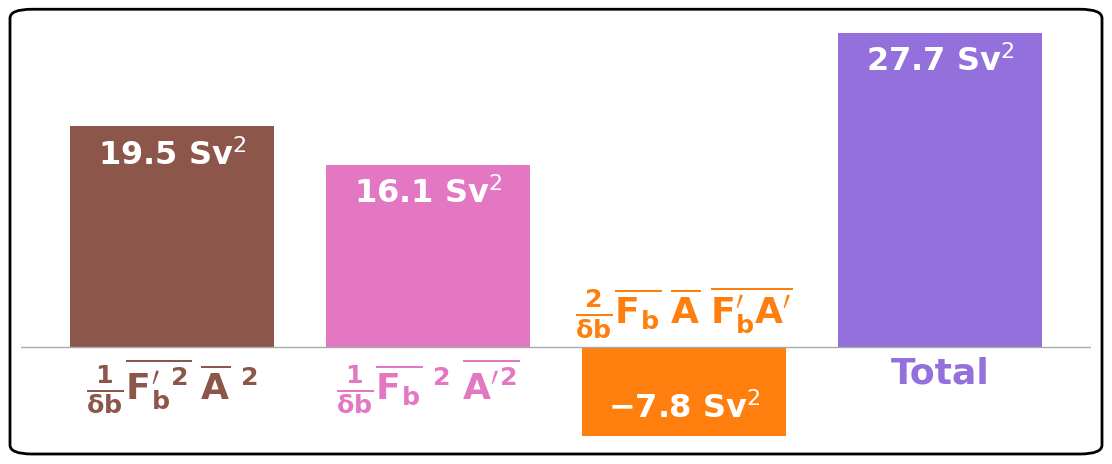

In [63]:
fig, ax = plt.subplots(figsize=(11,4.5))
dsigma2 = 0.05 ** 2
values = [np.nanmean(filter_siz_only(a)) / dsigma2 * ((1e-6) ** 2), 
          np.nanmean(filter_siz_only(b)) / dsigma2 * ((1e-6) ** 2), 
          np.nanmean(filter_siz_only(c)) / dsigma2 * ((1e-6) ** 2)] + \
         [np.nanmean(filter_siz_only(a + b + c)) / dsigma2 * ((1e-6) ** 2)]
meanvar_bar_colors = ['tab:brown', 'tab:pink', 'tab:orange', 'mediumpurple']

bar_container = ax.bar([
                        r"$\bf{\overline{F_b'^2}\ \overline{A}\ ^2}$", 
                        r"$\bf{\overline{F_b}\ ^2\ \overline{A'^2}}$", 
                        r"$\bf{2\overline{F_b}\ \overline{A}\ \overline{F_b'A'}}$"] + 
                       ['Total'], 
                       values,
                       color=meanvar_bar_colors)

# ylim = ax.get_ylim()
ax.set_ylim(-0.8e1, 2.9e1)
ax.tick_params(axis='x', length=0)
ax.set_xticklabels([])
ax.axhline(0, linewidth=1, color='darkgrey')

# --- format bar VALUES as x10^n (LaTeX) instead of e+n ---
def sci_label(val):
    # if val == 0:
    #     return "0"
    # exp = 1# int(np.floor(np.log10(abs(val))))
    # mant = val / 10**exp
    # return fr"$\mathbf{{{mant:.1f}\times10^{{{exp}}}}}$"
    return fr"$\mathbf{{{val:.1f}}}$"

bar_value_labels = [sci_label(v) + r" Sv$^2$" for v in values]
ax.bar_label(bar_container, labels=bar_value_labels, size=23, padding=-32,
             color='white', fontweight='bold')

# --- bar LABELS (category names) placed at the base of each bar ---
labels = [
    r"$\bf{\frac{1}{\delta b}\overline{F_b'^2}\ \overline{A}\ ^2}$", 
    r"$\bf{\frac{1}{\delta b}\overline{F_b}\ ^2\ \overline{A'^2}}$", 
    r"$\bf{\frac{2}{\delta b}\overline{F_b}\ \overline{A}\ \overline{F_b'A'}}$",
    'Total'
]
base_label_pad = 6  # points, distance from the zero line
for bar, val, label, color in zip(bar_container, values, labels, meanvar_bar_colors):
    x = bar.get_x() + bar.get_width() / 2
    if val >= 0:
        va, offset_pts = 'top', -base_label_pad
    else:
        va, offset_pts = 'bottom', base_label_pad
    ax.annotate(
        label,
        xy=(x, 0),
        xytext=(0, offset_pts),
        textcoords='offset points',
        ha='center', va=va,
        fontsize=26, color=color, fontweight='bold',
    )

# --- legend-style framing (rounded, like a real legend) ---
# no y-axis at all now — hide every spine
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# remove y ticks/labels entirely
ax.set_yticks([])
ax.tick_params(axis='y', length=0, labelleft=False)

fig.patch.set_facecolor('none')
fig.canvas.draw()
fig.tight_layout()
fig.canvas.draw()

# get axes bbox in figure coordinates, then pad it out — no y-axis labels now,
# so left/top padding can shrink; keep a little room for the bar-base labels
bbox = ax.get_position()
pad_left   = 0.01
pad_right  = 0.01
pad_top    = 0.02
pad_bottom = 0.035
frame = FancyBboxPatch(
    (bbox.x0 - pad_left, bbox.y0 - pad_bottom),
    bbox.width + pad_left + pad_right,
    bbox.height + pad_top + pad_bottom,
    boxstyle="round,pad=0,rounding_size=0.02",
    transform=fig.transFigure,
    facecolor='white',
    edgecolor='black',
    linewidth=2.0,
    zorder=-1,
    clip_on=False,
)
fig.add_artist(frame)
fig.savefig('manuscript_figs/var_decomp_bars.png', facecolor='white', bbox_inches='tight', dpi=1200)

<>:132: SyntaxWarning: invalid escape sequence '\s'
<>:132: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1511836/2223616575.py:132: SyntaxWarning: invalid escape sequence '\s'
  ax4.set_xlabel('$\sigma_2$ [$kg~m^{-3}$]', fontsize=label_fontsize, labelpad=2)


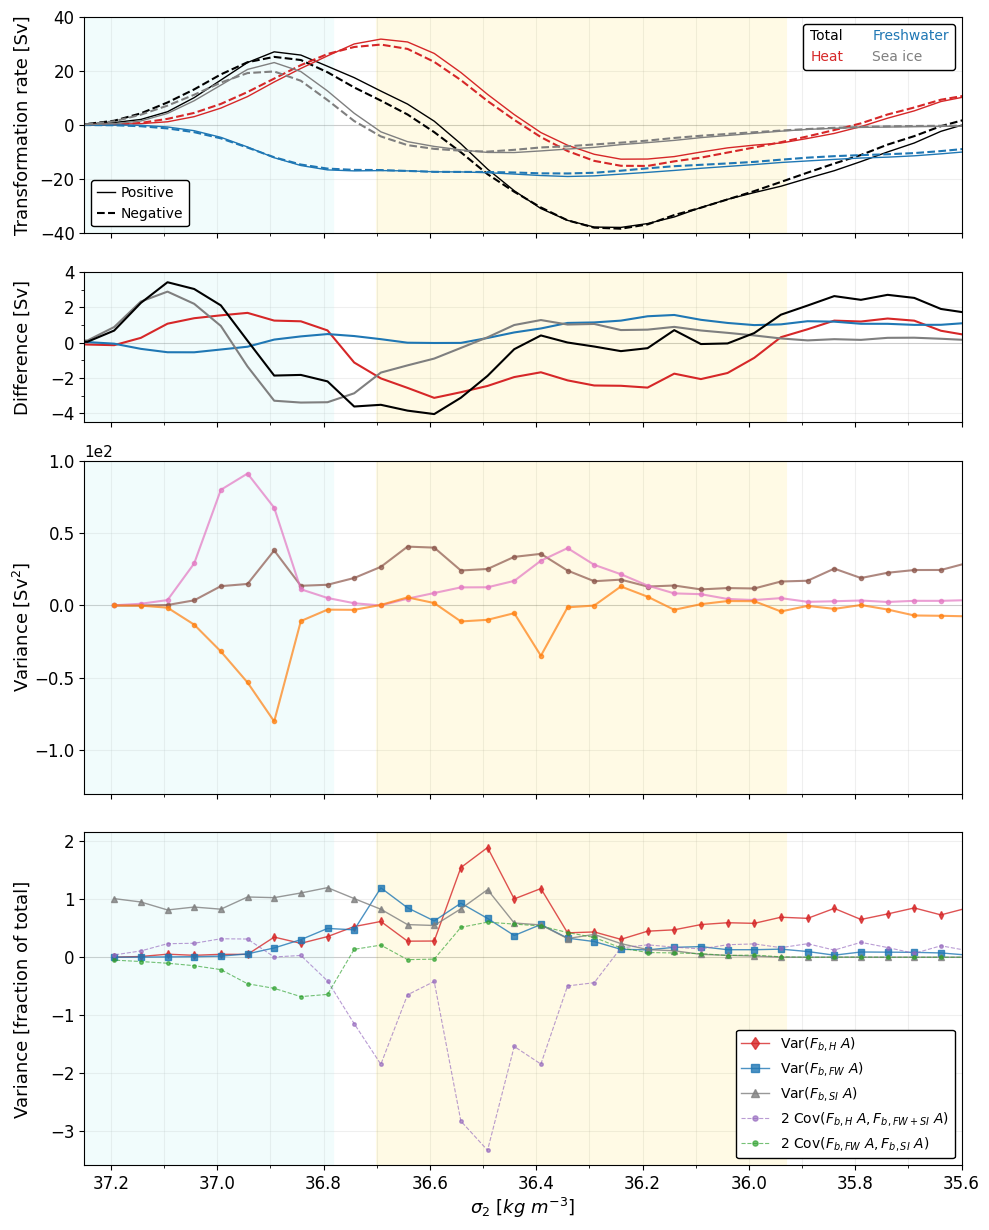

In [53]:
# figure setup
height_ratios = [3.25, 2.25, 5, 5]
total_units = sum(height_ratios)
unit = 4 / 5  # from fig1: figsize height 4 corresponds to ratio sum 5
fig_height = total_units * unit
frameon = True

fig, axes = plt.subplots(4, 1, figsize=(10, fig_height), sharex=True,
                          gridspec_kw={'height_ratios': height_ratios})
ax, ax2, ax3, ax4 = axes

for axx in (ax, ax2, ax3, ax4):
    axx.axhline(0, c='k', alpha=0.15, lw=0.8)
    axx.axvline(rholevs[260] - 1000, c='paleturquoise', alpha=0.17, linewidth=201)
    axx.axvline(rholevs[246] - 1000.025, c='gold', alpha=0.1, linewidth=296)
    axx.set_xlim(sigma2_xlim)
    axx.tick_params(axis='both', labelsize=tick_labelsize)

# ============ PANEL 1: composite ============
for j, (var, color) in enumerate(zip(wmt_vars, wmt_colors)):
    for i, period in enumerate(group_names):
        y = outputs_periods[i][j]
        if var == "freshwater":
            y = y - outputs_periods[i][3]
        y_smooth = savgol_filter(y, window_size, poly_order)
        if i == 0:
            linewidth = 1
            label_adjusted = var.capitalize()
        else:
            linewidth = 1.5
            label_adjusted = ''
        ax.plot(
            sigma2s, y_smooth,
            color=color,
            linestyle=wmt_linestyles[i % len(wmt_linestyles)],
            linewidth=linewidth,
            label=label_adjusted
        )

# ax.grid(True, axis="both", alpha=grid_alpha)

# legend #1: colors -> variables
var_legend = ax.legend(fontsize=legend_fontsize, labelcolor=list(wmt_colors), handlelength=0,
                        handletextpad=0.1, loc='upper right', ncol=2, frameon=frameon, edgecolor='black', framealpha=1)
ax.add_artist(var_legend)  # keep this legend when the second one is added below

# legend #2: linestyles -> periods
style_handles = [
    Line2D([0], [0], color='k',
           linestyle=wmt_linestyles[i % len(wmt_linestyles)],
           linewidth=1 if i == 0 else 1.5,
           label=period.capitalize())
    for i, period in enumerate(group_names)
]
ax.legend(handles=style_handles, fontsize=legend_fontsize, handlelength=1.3,
          handletextpad=0.4, loc='lower left', frameon=frameon, edgecolor='black', framealpha=1)

ax.set_ylim([-40, 40])
ax.set_yticks(np.arange(-40, 41, 20))
ax.xaxis.set_minor_locator(MultipleLocator(0.1))
ax.xaxis.grid(True, which='both', alpha=grid_alpha)
ax.yaxis.grid(True, alpha=grid_alpha)
ax.set_ylabel("Transformation rate [Sv]", fontsize=label_fontsize, labelpad=2)

# ============ PANEL 2: differences ============
ax2.plot(sigma2s, savgol_filter(yh_diff, window_size, poly_order), c=wmt_colors[1], linewidth=1.5, linestyle='-')
ax2.plot(sigma2s, savgol_filter(yfw_nosi_diff, window_size, poly_order), c=wmt_colors[2], linewidth=1.5, linestyle='-')
ax2.plot(sigma2s, savgol_filter(ysi_diff, window_size, poly_order), c=wmt_colors[3], linewidth=1.5, linestyle='-')
ax2.plot(sigma2s, savgol_filter(yt_diff, window_size, poly_order), c=wmt_colors[0], linewidth=1.5)

ax2.set_ylim([-4.5, 4])
ax2.set_yticks(np.arange(-4, 4.1, 2))
ax2.xaxis.grid(True, which='both', alpha=grid_alpha)
ax2.yaxis.grid(True, alpha=grid_alpha)
ax2.xaxis.set_minor_locator(MultipleLocator(0.1))
ax2.yaxis.set_minor_locator(MultipleLocator(1))
ax2.set_ylabel('Difference [Sv]', fontsize=label_fontsize, labelpad=2)

# ============ PANEL 3: variance decomposition vs sigma2 ============
ms = 3
dsigma2 = 0.05 ** 2

ax3.plot(sigma2s, (a / dsigma2) * ((1e-6) ** 2), c='tab:brown',
         label=r"$\overline{F_b'^2}\ \overline{A}^2$", ms=ms, alpha=0.7, marker='o')
ax3.plot(sigma2s, (b / dsigma2) * ((1e-6) ** 2), c='tab:pink',
         label=r"$\overline{F_b}^2\ \overline{A'^2}$", ms=ms, alpha=0.7, marker='o')
ax3.plot(sigma2s, (c / dsigma2) * ((1e-6) ** 2), c='tab:orange',
         label=r"$2\overline{F_b}\ \overline{A}\ \overline{F_b'A'}$", ms=ms, alpha=0.7, marker='o')

ax3.xaxis.set_minor_locator(MultipleLocator(0.1))
ax3.xaxis.grid(True, which='both', alpha=grid_alpha)
ax3.yaxis.grid(True, alpha=grid_alpha)

formatter = ScalarFormatter()
formatter.set_scientific(True)
formatter.set_powerlimits((-1, 1))
ax3.yaxis.set_major_formatter(formatter)
ax3.yaxis.get_offset_text().set_fontsize(tick_labelsize - 1)
ax3.set_ylim(-13e1, 10e1)
ax3.set_ylabel(r'Variance [Sv$^2$]', labelpad=2, fontsize=label_fontsize)

# ============ PANEL 4: variance fraction ============
colors_markers = {
    'heat': ('tab:red', 'd'),
    'fw': ('tab:blue', 's'),
    'si': ('tab:grey', '^'),
}

var_labels = {
    'heat': r"Var$(F_{b,H}~A)$",
    'fw': r"Var$(F_{b,FW}~A)$",
    'si': r"Var$(F_{b,SI}~A)$",
    'addl_heat_fw': r"2 Cov$(F_{b,H}~A,F_{b,FW + SI}~A)$",
    'addl_fw_si': r"2 Cov$(F_{b,FW}~A,F_{b,SI}~A)$"
}

for var_name, var_component in var_components.items():
    color, marker = colors_markers[var_name]
    ax4.plot(sigma2s, var_component / total_var_all_components, marker=marker, ms=4,
             c=color, label=var_labels[var_name], linewidth=1, alpha=0.8)

ax4.plot(sigma2s, addl_terms_heat_fw / total_var_all_components, c='tab:purple', lw=0.8,
         label=var_labels['addl_heat_fw'], marker='.', ms=5, alpha=0.65, linestyle='--')
ax4.plot(sigma2s, addl_terms_precip_si / total_var_all_components, c='tab:green', lw=0.8,
         label=var_labels['addl_fw_si'], marker='.', ms=5, alpha=0.65, linestyle='--')

ax4.legend(fontsize=legend_fontsize, markerscale=1.5, frameon=frameon, loc='lower right', edgecolor='black',framealpha=1)

ax4.xaxis.set_minor_locator(MultipleLocator(0.1))
ax4.xaxis.grid(True, which='both', alpha=grid_alpha)
ax4.yaxis.grid(True, alpha=grid_alpha)
ax4.set_xlabel('$\sigma_2$ [$kg~m^{-3}$]', fontsize=label_fontsize, labelpad=2)
ax4.set_ylabel('Variance [fraction of total]', labelpad=2, fontsize=label_fontsize)

fig.align_ylabels(axes)
fig.tight_layout()
fig.subplots_adjust(hspace=0.15)
plt.show()
fig.savefig('manuscript_figs/wmt_fig3.png', dpi=1200)